## 0. Setup e Imports

In [5]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from ipynb.fs.defs.competition1 import create_sparse_matrix, compute_stats

In [ ]:
from pmf import PMF
from svdpp import SVDpp
from lightfm import LightFM

In [7]:
y = df["rating"]
x = df.drop(columns="rating")
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=42, stratify=df.rating)

In [8]:
sparse_matrix, user_map, item_map = create_sparse_matrix(x_train, y_train)
user_means, item_means, global_mean = compute_stats(sparse_matrix)

In [ ]:
# Medias necesarias para el cold-start de LightFM
user_means  = y_train.groupby(x_train['user']).mean().to_dict()
item_means  = y_train.groupby(x_train['item']).mean().to_dict()
global_mean = float(y_train.mean())

In [ ]:
file_test = "data/test.csv"
df_test = pd.read_csv(file_test, header=0)

## 1. Grid Search PMF — Resultados

5 rondas de búsqueda de hiperparámetros. A partir de la 2ª se cambió a split
**cold-start** (usuarios enteros excluidos del train) para simular mejor el entorno Kaggle.

| Grid | n_factors | lr | reg | reg_bias | Mejor val MAE | Split |
|------|-----------|-----|-----|----------|--------------|-------|
| 1 | 200–400 | 0.010–0.020 | 0.02–0.04 | 0.0005–0.002 | **1.2449** (f=200, lr=0.01, reg=0.02, rb=0.001) | Aleatorio |
| 2 | 400–800 | 0.012–0.018 | 0.04–0.08 | 0.0005–0.002 | 1.4741 (f=800, lr=0.012, reg=0.08, rb=0.0005) | Cold-start |
| 3 | 800–1200 | 0.012–0.016 | 0.09–0.10 | 0.0005–0.002 | 1.4741 (f=800, lr=0.016, reg=0.10, rb=0.001) | Cold-start |
| 4 | 800–900 | 0.016–0.020 | 0.10–0.12 | 0.001–0.002 | 1.4740 (f=900, lr=0.02, reg=0.11, rb=0.0015) | Cold-start |
| 5 | 800 (fijo) | 0.014–0.017 | 0.09–0.105 | 0.0008–0.0012 | 1.4741 (f=800, lr=0.016, reg=0.105, rb=0.001) | Cold-start |

> **Configuración adoptada:** `n_factors=800, lr=0.016, reg=0.10, reg_bias=0.001`  
> La diferencia de MAE entre Grid 1 (∼1.24) y Grids 2–5 (∼1.47) se debe al cambio de
> tipo de split, no a un empeoramiento del modelo.


## 2. Ensemble PMF — Configuración óptima

9 modelos PMF con la config ganadora del grid search (`n_factors=800, lr=0.016, reg=0.10`),
seeds distintas para diversidad. Cold-start gestionado con estrategias óptimas de
`analyze_coldstart`. Val MAE resultante: **1.2316**.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FASE 1 — Sin datos nuevos
# ① Reentrenar con train+val completo para test
# ② Biases aprendidos como cold-start
# ③ Ensemble PMF + KNN sobre conocidos
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


# ── PASO 0: Utilidades compartidas ────────────────────────────────────────────

def evaluate_predictions(preds, y_true, label=''):
    mae  = np.mean(np.abs(preds - y_true))
    rmse = np.sqrt(np.mean((preds - y_true) ** 2))
    print(f"{label:<30} MAE={mae:.4f}  RMSE={rmse:.4f}")
    return mae, rmse


def evaluate_disaggregated(preds, y_true, known_mask, label='Model'):
    """Evalúa separando casos conocidos de cold-start."""
    print(f"\n── {label} ──────────────────────────────────────────")
    mae_total, rmse_total = evaluate_predictions(preds, y_true,
                                                  f"  Total      ({len(y_true):>5})")
    mae_k, _ = evaluate_predictions(preds[known_mask],  y_true[known_mask],
                                     f"  Conocidos  ({known_mask.sum():>5})")
    mae_c, _ = evaluate_predictions(preds[~known_mask], y_true[~known_mask],
                                     f"  Cold-start ({(~known_mask).sum():>5})")
    return {'total': mae_total, 'known': mae_k, 'cold': mae_c}


# ── PASO 1: Reentrenar con train+val ─────────────────────────────────────────

def retrain_full(x_train, y_train, x_val, y_val, pmf_params,
                 n_epochs_full=None, patience_val=10):
    """
    ① Determina épocas óptimas entrenando con train/val
    ② Reentrena con train+val usando esas épocas fijas

    pmf_params : dict con los hiperparámetros de PMF (sin n_epochs)
    """

    # ── 1A: encontrar n_epochs óptimo con train/val ───────────────────────────
    print("═" * 60)
    print("STEP 1A — Encontrando épocas óptimas con train/val...")
    print("═" * 60)

    sparse_tv, user_map_tv, item_map_tv = create_sparse_matrix(x_train, y_train)
    user_means_tv, item_means_tv, global_mean_tv = compute_stats(sparse_tv)

    pmf_val = PMF(**pmf_params)
    pmf_val.fit(x_train, y_train, x_val, y_val,
                user_map_tv, item_map_tv, patience=patience_val)

    best_epoch = int(pd.DataFrame(pmf_val.history)['val_mae'].idxmin()) + 1
    print(f"\n→ Épocas óptimas encontradas: {best_epoch}")

    if n_epochs_full is not None:
        best_epoch = n_epochs_full
        print(f"→ Sobreescrito por n_epochs_full={n_epochs_full}")

    # ── 1B: reentrenar con train+val ─────────────────────────────────────────
    print("\n" + "═" * 60)
    print(f"STEP 1B — Reentrenando con train+val ({best_epoch} épocas)...")
    print("═" * 60)

    x_full = pd.concat([x_train, x_val]).reset_index(drop=True)
    y_full = pd.concat([y_train, y_val]).reset_index(drop=True)

    sparse_full, user_map_full, item_map_full = create_sparse_matrix(x_full, y_full)
    user_means_full, item_means_full, global_mean_full = compute_stats(sparse_full)

    full_params = {**pmf_params, 'n_epochs': best_epoch}
    pmf_full = PMF(**full_params)

    # val = train para que no rompa el código, patience=999 para no parar
    pmf_full.fit(x_full, y_full, x_full, y_full,
                 user_map_full, item_map_full, patience=999)

    print(f"\n✔ Modelo reentrenado con {len(x_full)} muestras")
    print(f"  Usuarios en train+val : {len(user_map_full)}")
    print(f"  Ítems en train+val    : {len(item_map_full)}")

    return (pmf_full, sparse_full, user_map_full, item_map_full,
            user_means_full, item_means_full, global_mean_full,
            pmf_val, sparse_tv, user_map_tv, item_map_tv,
            user_means_tv, item_means_tv, global_mean_tv)


# ── PASO 2: Predicción PMF con biases como cold-start ────────────────────────

def predict_pmf_with_bias_coldstart(pmf, x, user_map, item_map,
                                     clip_min=1.0, clip_max=10.0,
                                     has_id_col=False):
    """
    ② Usa biases aprendidos para cold-start en lugar de constantes:
        usuario conocido,  ítem desconocido → μ + b_u[u]
        usuario desconocido, ítem conocido  → μ + b_i[i]
        ambos desconocidos                  → μ
        ambos conocidos                     → μ + b_u + b_i + U·V
    """
    ids, preds = [], []

    for _, row in tqdm(x.iterrows(), total=len(x), desc='Predicting PMF'):
        if has_id_col:
            row_id  = row.iloc[0]
            user_id = row.iloc[1]
            item_id = row.iloc[2]
            ids.append(row_id)
        else:
            user_id = row.iloc[0]
            item_id = row.iloc[1]

        u_known = user_id in user_map
        i_known = item_id in item_map

        if u_known and i_known:
            u = user_map[user_id]
            i = item_map[item_id]
            p = pmf.mu + pmf.b_u[u] + pmf.b_i[i] + np.dot(pmf.U[u], pmf.V[i])

        elif u_known and not i_known:
            # ② bias usuario como cold-start para ítem desconocido
            u = user_map[user_id]
            p = pmf.mu + pmf.b_u[u]

        elif not u_known and i_known:
            # ② bias ítem como cold-start para usuario desconocido
            i = item_map[item_id]
            p = pmf.mu + pmf.b_i[i]

        else:
            # ambos desconocidos → solo media global
            p = pmf.mu

        preds.append(np.clip(p, clip_min, clip_max))

    if has_id_col:
        return pd.DataFrame({'id': ids, 'rating': preds})
    return np.array(preds)


# ── PASO 3: Predicción KNN ────────────────────────────────────────────────────

def predict_knn_array(x_val, sparse_matrix, user_map, item_map,
                      user_means, item_means, global_mean,
                      metric='jaccard_weighted', k=5,
                      cold_start_unknown_user='global_mean',
                      cold_start_unknown_item='user_mean',
                      cold_start_both='const_7',
                      clip_min=1.0, clip_max=10.0):
    """Predicción KNN devolviendo np.array (para ensemble en val)."""

    def _cold(strat, user_idx=None, item_idx=None):
        if strat == 'item_mean':
            v = item_means[item_idx] if item_idx is not None else np.nan
        elif strat == 'user_mean':
            v = user_means[user_idx] if user_idx is not None else np.nan
        elif strat == 'global_mean':
            v = global_mean
        elif strat.startswith('const_'):
            v = float(strat.split('_')[1])
        else:
            v = np.nan
        return global_mean if (isinstance(v, float) and np.isnan(v)) else v

    preds = []
    for _, row in tqdm(x_val.iterrows(), total=len(x_val), desc='Predicting KNN'):
        user_id = row.iloc[0]
        item_id = row.iloc[1]

        u_known = user_id in user_map
        i_known = item_id in item_map

        if not u_known and not i_known:
            preds.append(_cold(cold_start_both))
            continue
        if not u_known:
            preds.append(_cold(cold_start_unknown_user, item_idx=item_map[item_id]))
            continue
        if not i_known:
            preds.append(_cold(cold_start_unknown_item, user_idx=user_map[user_id]))
            continue

        user_idx = user_map[user_id]
        item_idx = item_map[item_id]

        distances, ratings, _ = get_user_distances_for_item(
            user_idx, item_idx, sparse_matrix, [metric], user_means
        )
        distances = distances[metric]

        if len(distances) == 0:
            preds.append(_cold(cold_start_unknown_item, user_idx=user_idx))
            continue

        sorted_idx = np.argsort(distances)
        top_idx    = sorted_idx[:min(k, len(sorted_idx))]
        top_d      = distances[top_idx]
        top_r      = ratings[top_idx]
        weights    = 1 / (top_d + 1e-8)
        preds.append(np.clip(np.dot(weights, top_r) / weights.sum(), clip_min, clip_max))

    return np.array(preds)


# ── PASO 4: Ensemble ──────────────────────────────────────────────────────────

def find_best_alpha(val_preds_pmf, val_preds_knn, y_val,
                    known_mask=None, clip_min=1.0, clip_max=10.0):
    """
    ③ Busca el mejor alpha sobre los casos conocidos (donde KNN y PMF aportan).
    Si known_mask=None evalúa sobre todos.
    """
    mask  = known_mask if known_mask is not None else np.ones(len(y_val), dtype=bool)
    p_pmf = val_preds_pmf[mask]
    p_knn = val_preds_knn[mask]
    y     = y_val[mask]

    alphas, results = np.arange(0, 1.05, 0.05), []
    for alpha in alphas:
        blended = np.clip(alpha * p_pmf + (1 - alpha) * p_knn, clip_min, clip_max)
        mae     = np.mean(np.abs(blended - y))
        rmse    = np.sqrt(np.mean((blended - y) ** 2))
        results.append({'alpha': alpha, 'mae': mae, 'rmse': rmse})

    df      = pd.DataFrame(results)
    best    = df.loc[df['mae'].idxmin()]
    best_alpha = float(best['alpha'])

    print(f"\n{'Alpha':>7}  {'MAE':>8}  {'RMSE':>8}")
    print("─" * 30)
    for _, r in df.iterrows():
        marker = '  ✔ best' if r['alpha'] == best_alpha else ''
        print(f"{r['alpha']:>7.2f}  {r['mae']:>8.4f}  {r['rmse']:>8.4f}{marker}")

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, title in [(ax1, 'mae', 'MAE'), (ax2, 'rmse', 'RMSE')]:
        ax.plot(df['alpha'], df[metric], marker='o', linewidth=2)
        ax.axvline(best_alpha, color='red', linestyle='--',
                   label=f'Best α={best_alpha:.2f} ({best[metric]:.4f})')
        ax.axhline(np.mean(np.abs(p_pmf - y)) if metric == 'mae'
                   else np.sqrt(np.mean((p_pmf - y)**2)),
                   color='steelblue', linestyle=':', label='PMF solo')
        ax.axhline(np.mean(np.abs(p_knn - y)) if metric == 'mae'
                   else np.sqrt(np.mean((p_knn - y)**2)),
                   color='darkorange', linestyle=':', label='KNN solo')
        ax.set_xlabel('Alpha  (0=KNN, 1=PMF)')
        ax.set_ylabel(title)
        ax.set_title(f'Ensemble — {title}')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.4)
    suffix = f'sobre conocidos ({mask.sum()})' if known_mask is not None else 'total'
    fig.suptitle(f'PMF + KNN Ensemble ({suffix})', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    return best_alpha


def ensemble_test(pmf_full, x_test,
                  sparse_tv, user_map_tv, item_map_tv,
                  user_means_tv, item_means_tv, global_mean_tv,
                  user_map_full, item_map_full,
                  best_alpha, k, metric='jaccard_weighted',
                  clip_min=1.0, clip_max=10.0):
    """Genera predicciones finales de test con el ensemble."""

    print("Generando predicciones PMF (train+val)...")
    x_test_noid = x_test.iloc[:, 1:]   # quitar columna id
    preds_pmf   = predict_pmf_with_bias_coldstart(
        pmf_full, x_test_noid, user_map_full, item_map_full,
        clip_min=clip_min, clip_max=clip_max, has_id_col=False
    )

    print("Generando predicciones KNN (train only)...")
    preds_knn = predict_knn_array(
        x_test_noid, sparse_tv, user_map_tv, item_map_tv,
        user_means_tv, item_means_tv, global_mean_tv,
        metric=metric, k=k, clip_min=clip_min, clip_max=clip_max
    )

    blended = np.clip(best_alpha * preds_pmf + (1 - best_alpha) * preds_knn,
                      clip_min, clip_max)

    submission = pd.DataFrame({'id': x_test.iloc[:, 0].values, 'rating': blended})
    return submission

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm
from collections import Counter


# ═══════════════════════════════════════════════════════════════════════════════
# PASO 1 — Análisis cold-start sobre train+val
# ═══════════════════════════════════════════════════════════════════════════════

def analyze_coldstart(x_train, y_train, x_val, y_val, user_map, item_map):
    """
    Para cada caso de cold-start evalúa todas las estrategias posibles
    sobre los datos de validación y genera gráficas.

    Casos:
        unknown_user : usuario no está en train, ítem sí
        unknown_item : ítem no está en train, usuario sí
        both_unknown : ninguno está en train
    """

    # ── Estadísticas globales calculadas sobre train ──────────────────────────
    all_ratings    = y_train.values
    global_mean    = float(np.mean(all_ratings))
    global_median  = float(np.median(all_ratings))
    global_mode    = float(stats.mode(all_ratings, keepdims=True).mode[0])

    # Media/mediana/moda por usuario en train
    train_df = x_train.copy()
    train_df.columns = ['user', 'item']
    train_df['rating'] = y_train.values

    user_stats = train_df.groupby('user')['rating'].agg(
        mean='mean', median='median',
        mode=lambda x: stats.mode(x, keepdims=True).mode[0]
    )
    item_stats = train_df.groupby('item')['rating'].agg(
        mean='mean', median='median',
        mode=lambda x: stats.mode(x, keepdims=True).mode[0]
    )

    # ── Clasificar casos en val ───────────────────────────────────────────────
    val_df = x_val.copy()
    val_df.columns = ['user', 'item']
    val_df['rating'] = y_val.values
    val_df['u_known'] = val_df['user'].isin(user_map)
    val_df['i_known'] = val_df['item'].isin(item_map)

    cases = {
        'unknown_user' : val_df[ val_df['u_known'] & ~val_df['i_known']],  # usuario conocido, ítem no  -- wait, unknown_user means user not in train
        'unknown_item' : val_df[~val_df['u_known'] &  val_df['i_known']],  # ítem conocido, usuario no
        'both_unknown' : val_df[~val_df['u_known'] & ~val_df['i_known']],
    }
    # Fix: unknown_user = user NOT in train
    cases = {
        'unknown_user' : val_df[~val_df['u_known'] &  val_df['i_known']],
        'unknown_item' : val_df[ val_df['u_known'] & ~val_df['i_known']],
        'both_unknown' : val_df[~val_df['u_known'] & ~val_df['i_known']],
    }

    print(f"Casos cold-start en validación:")
    for case, df in cases.items():
        print(f"  {case:<15}: {len(df):>5} ({len(df)/len(val_df)*100:.1f}%)")

    best_strategies = {}

    for case, df in cases.items():
        if len(df) == 0:
            print(f"\n[{case}] Sin casos en validación, skipping.")
            continue

        y_true = df['rating'].values

        # ── Construir estrategias disponibles para este caso ──────────────────
        strategies = {}

        # Constantes 1-10
        for v in range(1, 11):
            strategies[f'const_{v}'] = np.full(len(df), float(v))

        # Globales
        strategies['global_mean']   = np.full(len(df), global_mean)
        strategies['global_median'] = np.full(len(df), global_median)
        strategies['global_mode']   = np.full(len(df), global_mode)

        # Basadas en ítem (cuando el ítem es conocido)
        if case == 'unknown_user':
            item_mean_preds, item_med_preds, item_mode_preds = [], [], []
            for item_id in df['item']:
                if item_id in item_stats.index:
                    item_mean_preds.append(item_stats.loc[item_id, 'mean'])
                    item_med_preds.append(item_stats.loc[item_id, 'median'])
                    item_mode_preds.append(item_stats.loc[item_id, 'mode'])
                else:
                    item_mean_preds.append(global_mean)
                    item_med_preds.append(global_median)
                    item_mode_preds.append(global_mode)
            strategies['item_mean']   = np.array(item_mean_preds)
            strategies['item_median'] = np.array(item_med_preds)
            strategies['item_mode']   = np.array(item_mode_preds)

        # Basadas en usuario (cuando el usuario es conocido)
        if case == 'unknown_item':
            user_mean_preds, user_med_preds, user_mode_preds = [], [], []
            for user_id in df['user']:
                if user_id in user_stats.index:
                    user_mean_preds.append(user_stats.loc[user_id, 'mean'])
                    user_med_preds.append(user_stats.loc[user_id, 'median'])
                    user_mode_preds.append(user_stats.loc[user_id, 'mode'])
                else:
                    user_mean_preds.append(global_mean)
                    user_med_preds.append(global_median)
                    user_mode_preds.append(global_mode)
            strategies['user_mean']   = np.array(user_mean_preds)
            strategies['user_median'] = np.array(user_med_preds)
            strategies['user_mode']   = np.array(user_mode_preds)

        # ── Calcular MAE para cada estrategia ─────────────────────────────────
        results = {}
        for name, preds in strategies.items():
            results[name] = float(np.mean(np.abs(preds - y_true)))

        results_df = pd.DataFrame({'strategy': list(results.keys()),
                                   'mae': list(results.values())})
        results_df = results_df.sort_values('mae').reset_index(drop=True)
        best_strat = results_df.iloc[0]['strategy']
        best_strategies[case] = {
            'strategy' : best_strat,
            'mae'      : results_df.iloc[0]['mae'],
            'all'      : results_df
        }

        print(f"\n── {case} (n={len(df)}) ──────────────────────────────")
        print(results_df.to_string(index=False))
        print(f"  → Mejor estrategia: {best_strat} (MAE={results_df.iloc[0]['mae']:.4f})")

        # ── Plot ──────────────────────────────────────────────────────────────
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

        # Barras MAE por estrategia
        colors = ['#70ad47' if s == best_strat else
                  '#5b9bd5' if s.startswith('const_') else
                  '#ed7d31' if 'mean' in s or 'median' in s or 'mode' in s else
                  '#a9a9a9'
                  for s in results_df['strategy']]

        bars = ax1.bar(range(len(results_df)), results_df['mae'],
                       color=colors, edgecolor='white')
        ax1.set_xticks(range(len(results_df)))
        ax1.set_xticklabels(results_df['strategy'], rotation=45, ha='right', fontsize=8)
        ax1.set_ylabel('MAE')
        ax1.set_title(f'[{case}] MAE por estrategia')
        ax1.grid(True, axis='y', alpha=0.4)

        y_off = (results_df['mae'].max() - results_df['mae'].min()) * 0.01 + 0.001
        for bar, val in zip(bars, results_df['mae']):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_off,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=7)

        from matplotlib.patches import Patch
        ax1.legend(handles=[
            Patch(color='#70ad47', label='Best'),
            Patch(color='#5b9bd5', label='Constant (1-10)'),
            Patch(color='#ed7d31', label='Stat-based'),
        ], fontsize=8)

        # Distribución de ratings reales en este caso
        ax2.hist(y_true, bins=np.arange(0.5, 11.5, 1), color='steelblue',
                 edgecolor='white', alpha=0.8)
        ax2.axvline(global_mean,   color='red',    linestyle='--', label=f'global mean={global_mean:.2f}')
        ax2.axvline(global_median, color='orange', linestyle='--', label=f'global median={global_median:.2f}')
        ax2.set_xlabel('Rating')
        ax2.set_ylabel('Count')
        ax2.set_title(f'[{case}] Distribución de ratings reales')
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.4)

        fig.suptitle(f'Cold-start analysis — {case}', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return best_strategies, user_stats, item_stats, global_mean


# ═══════════════════════════════════════════════════════════════════════════════
# PASO 2+3 — Entrenamiento ensemble de PMF con diferentes semillas
# ═══════════════════════════════════════════════════════════════════════════════

def _cold_pred_from_strategy(strategy_name, user_id, item_id,
                              user_stats, item_stats, global_mean):
    """Aplica la estrategia de cold-start a una muestra concreta."""
    if strategy_name.startswith('const_'):
        return float(strategy_name.split('_')[1])
    if strategy_name == 'global_mean':
        return global_mean
    if strategy_name == 'item_mean':
        return item_stats.loc[item_id, 'mean'] if item_id in item_stats.index else global_mean
    if strategy_name == 'item_median':
        return item_stats.loc[item_id, 'median'] if item_id in item_stats.index else global_mean
    if strategy_name == 'item_mode':
        return item_stats.loc[item_id, 'mode'] if item_id in item_stats.index else global_mean
    if strategy_name == 'user_mean':
        return user_stats.loc[user_id, 'mean'] if user_id in user_stats.index else global_mean
    if strategy_name == 'user_median':
        return user_stats.loc[user_id, 'median'] if user_id in user_stats.index else global_mean
    if strategy_name == 'user_mode':
        return user_stats.loc[user_id, 'mode'] if user_id in user_stats.index else global_mean
    return global_mean


def predict_pmf_real_mae(pmf, x_val, y_val, user_map, item_map,
                         best_strategies, user_stats, item_stats, global_mean,
                         clip_min=1.0, clip_max=10.0):
    """
    Predicción en val usando las mejores estrategias de cold-start.
    Devuelve (preds_array, real_mae).
    """
    cs_unknown_user = best_strategies['unknown_user']['strategy']
    cs_unknown_item = best_strategies['unknown_item']['strategy']
    cs_both         = best_strategies['both_unknown']['strategy']

    preds = []
    for _, row in x_val.iterrows():
        user_id = row.iloc[0]
        item_id = row.iloc[1]
        u_known = user_id in user_map
        i_known = item_id in item_map

        if not u_known and not i_known:
            p = _cold_pred_from_strategy(cs_both, user_id, item_id,
                                          user_stats, item_stats, global_mean)
        elif not u_known:
            p = _cold_pred_from_strategy(cs_unknown_user, user_id, item_id,
                                          user_stats, item_stats, global_mean)
        elif not i_known:
            p = _cold_pred_from_strategy(cs_unknown_item, user_id, item_id,
                                          user_stats, item_stats, global_mean)
        else:
            u = user_map[user_id]
            i = item_map[item_id]
            p = pmf.mu + pmf.b_u[u] + pmf.b_i[i] + np.dot(pmf.U[u], pmf.V[i])
            p = float(np.clip(p, clip_min, clip_max))

        preds.append(p)

    preds    = np.array(preds)
    real_mae = float(np.mean(np.abs(preds - y_val.values)))
    return preds, real_mae


def train_pmf_ensemble(x_train, y_train, x_val, y_val,
                       user_map, item_map,
                       best_strategies, user_stats, item_stats, global_mean,
                       pmf_params, n_models=5, seeds=None,
                       clip_min=1.0, clip_max=10.0):
    """
    Entrena n_models PMF con semillas distintas.
    Para cada modelo guarda:
        - época de parada
        - MAE real en validación (con cold-start óptimo)
        - predicciones en validación
        - el propio modelo
    """
    if seeds is None:
        seeds = list(range(n_models))

    ensemble_info = []

    for idx, seed in enumerate(seeds):
        print(f"\n{'═'*60}")
        print(f"  Modelo {idx+1}/{n_models}  —  seed={seed}")
        print(f"{'═'*60}")

        params = {**pmf_params, 'random_state': seed}
        pmf    = PMF(**params)
        pmf.fit(x_train, y_train, x_val, y_val,
                user_map, item_map,
                patience=3)

        stop_epoch = len(pmf.history)
        val_preds, real_mae = predict_pmf_real_mae(
            pmf, x_val, y_val, user_map, item_map,
            best_strategies, user_stats, item_stats, global_mean,
            clip_min, clip_max
        )

        print(f"\n  → Stop epoch : {stop_epoch}")
        print(f"  → MAE real   : {real_mae:.4f}")

        ensemble_info.append({
            'seed'       : seed,
            'model'      : pmf,
            'stop_epoch' : stop_epoch,
            'real_mae'   : real_mae,
            'val_preds'  : val_preds,
        })

    return ensemble_info


# ═══════════════════════════════════════════════════════════════════════════════
# PASO 4 — Predicción ponderada por inverso de MAE
# ═══════════════════════════════════════════════════════════════════════════════

def weighted_predict(models_info, x, user_map, item_map,
                     best_strategies, user_stats, item_stats, global_mean,
                     clip_min=1.0, clip_max=10.0, has_id_col=False):
    """
    Predicción ensemble ponderada por 1/MAE.
    Más peso a los modelos con menor MAE de validación.
    """

    maes    = np.array([m['real_mae'] for m in models_info])
    weights = 1 / maes
    weights = weights / weights.sum()   # normalizar a suma=1

    print(f"\nPesos del ensemble:")
    for info, w in zip(models_info, weights):
        print(f"  seed={info['seed']}  MAE={info['real_mae']:.4f}  peso={w:.4f}")

    cs_unknown_user = best_strategies['unknown_user']['strategy']
    cs_unknown_item = best_strategies['unknown_item']['strategy']
    cs_both         = best_strategies['both_unknown']['strategy']

    ids_out, preds_out = [], []

    for _, row in tqdm(x.iterrows(), total=len(x), desc='Weighted predict'):
        if has_id_col:
            row_id  = row.iloc[0]
            user_id = row.iloc[1]
            item_id = row.iloc[2]
            ids_out.append(row_id)
        else:
            user_id = row.iloc[0]
            item_id = row.iloc[1]

        u_known = user_id in user_map
        i_known = item_id in item_map

        if not u_known and not i_known:
            p = _cold_pred_from_strategy(cs_both, user_id, item_id,
                                          user_stats, item_stats, global_mean)
            preds_out.append(p)
            continue

        if not u_known:
            p = _cold_pred_from_strategy(cs_unknown_user, user_id, item_id,
                                          user_stats, item_stats, global_mean)
            preds_out.append(p)
            continue

        if not i_known:
            p = _cold_pred_from_strategy(cs_unknown_item, user_id, item_id,
                                          user_stats, item_stats, global_mean)
            preds_out.append(p)
            continue

        # ── Pares conocidos: media ponderada de todos los modelos ─────────────
        model_preds = []
        for info in models_info:
            pmf = info['model']
            u   = user_map[user_id]
            i   = item_map[item_id]
            p   = pmf.mu + pmf.b_u[u] + pmf.b_i[i] + np.dot(pmf.U[u], pmf.V[i])
            model_preds.append(np.clip(p, clip_min, clip_max))

        p_final = float(np.dot(weights, model_preds))
        preds_out.append(np.clip(p_final, clip_min, clip_max))

    if has_id_col:
        return pd.DataFrame({'ID': ids_out, 'rating': preds_out})
    return np.array(preds_out)


# ═══════════════════════════════════════════════════════════════════════════════
# PASO 5 — Reentrenar sobre train+val con media de épocas de parada
# ═══════════════════════════════════════════════════════════════════════════════

def train_full_ensemble(x_train, y_train, x_val, y_val,
                        ensemble_info, pmf_params,
                        best_strategies, user_stats, item_stats,
                        n_models=5, seeds=None,
                        clip_min=1.0, clip_max=10.0):
    """
    ⑤ Reentrena el ensemble sobre train+val usando la media de épocas de parada.
    """
    mean_epochs = int(np.round(np.mean([m['stop_epoch'] for m in ensemble_info])))
    print(f"\nÉpocas de parada por modelo: {[m['stop_epoch'] for m in ensemble_info]}")
    print(f"Media de épocas → {mean_epochs}")

    x_full = pd.concat([x_train, x_val]).reset_index(drop=True)
    y_full = pd.concat([y_train, y_val]).reset_index(drop=True)

    sparse_full, user_map_full, item_map_full = create_sparse_matrix(x_full, y_full)
    user_means_full, item_means_full, global_mean_full = compute_stats(sparse_full)

    if seeds is None:
        seeds = [m['seed'] for m in ensemble_info]

    full_params = {**pmf_params, 'n_epochs': mean_epochs}
    full_ensemble_info = []

    for idx, seed in enumerate(seeds):
        print(f"\n{'═'*60}")
        print(f"  Modelo FULL {idx+1}/{n_models}  —  seed={seed}  epochs={mean_epochs}")
        print(f"{'═'*60}")

        params = {**full_params, 'random_state': seed}
        pmf    = PMF(**params)

        # val = train (sin early stopping real, épocas fijas)
        pmf.fit(x_full, y_full, x_full, y_full,
                user_map_full, item_map_full, patience=999)

        full_ensemble_info.append({
            'seed'  : seed,
            'model' : pmf,
            # MAE del modelo equivalente en val para mantener los pesos
            'real_mae' : ensemble_info[idx]['real_mae'],
        })

    return full_ensemble_info, user_map_full, item_map_full, global_mean_full


# ═══════════════════════════════════════════════════════════════════════════════
# PASO 6 — Resumen y plot del ensemble
# ═══════════════════════════════════════════════════════════════════════════════

def plot_ensemble_summary(ensemble_info):
    seeds       = [m['seed']       for m in ensemble_info]
    maes        = [m['real_mae']   for m in ensemble_info]
    stop_epochs = [m['stop_epoch'] for m in ensemble_info]
    weights     = 1 / np.array(maes); weights /= weights.sum()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # MAE por modelo
    colors = ['#70ad47' if m == min(maes) else '#5b9bd5' for m in maes]
    axes[0].bar([f'seed={s}' for s in seeds], maes, color=colors, edgecolor='white')
    axes[0].set_title('MAE real por modelo')
    axes[0].set_ylabel('MAE')
    axes[0].grid(True, axis='y', alpha=0.4)
    for i, v in enumerate(maes):
        axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

    # Pesos
    axes[1].bar([f'seed={s}' for s in seeds], weights, color='#ed7d31', edgecolor='white')
    axes[1].set_title('Pesos ensemble (1/MAE normalizado)')
    axes[1].set_ylabel('Peso')
    axes[1].grid(True, axis='y', alpha=0.4)
    for i, v in enumerate(weights):
        axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

    # Épocas de parada
    axes[2].bar([f'seed={s}' for s in seeds], stop_epochs, color='#9b59b6', edgecolor='white')
    axes[2].axhline(np.mean(stop_epochs), color='red', linestyle='--',
                    label=f'Media={np.mean(stop_epochs):.1f}')
    axes[2].set_title('Época de parada por modelo')
    axes[2].set_ylabel('Época')
    axes[2].legend(); axes[2].grid(True, axis='y', alpha=0.4)

    fig.suptitle('PMF Ensemble — Resumen', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

Casos cold-start en validación:
  unknown_user   :  3264 (8.4%)
  unknown_item   : 11212 (28.7%)
  both_unknown   :  1317 (3.4%)

── unknown_user (n=3264) ──────────────────────────────
     strategy      mae
      const_8 1.369792
global_median 1.369792
  global_mode 1.369792
  global_mean 1.428172
  item_median 1.458333
    item_mean 1.459555
      const_7 1.517463
    item_mode 1.649510
      const_9 1.754596
      const_6 2.043199
     const_10 2.439645
      const_5 2.750306
      const_4 3.648591
      const_3 4.594056
      const_2 5.570772
      const_1 6.560355
  → Mejor estrategia: const_8 (MAE=1.3698)


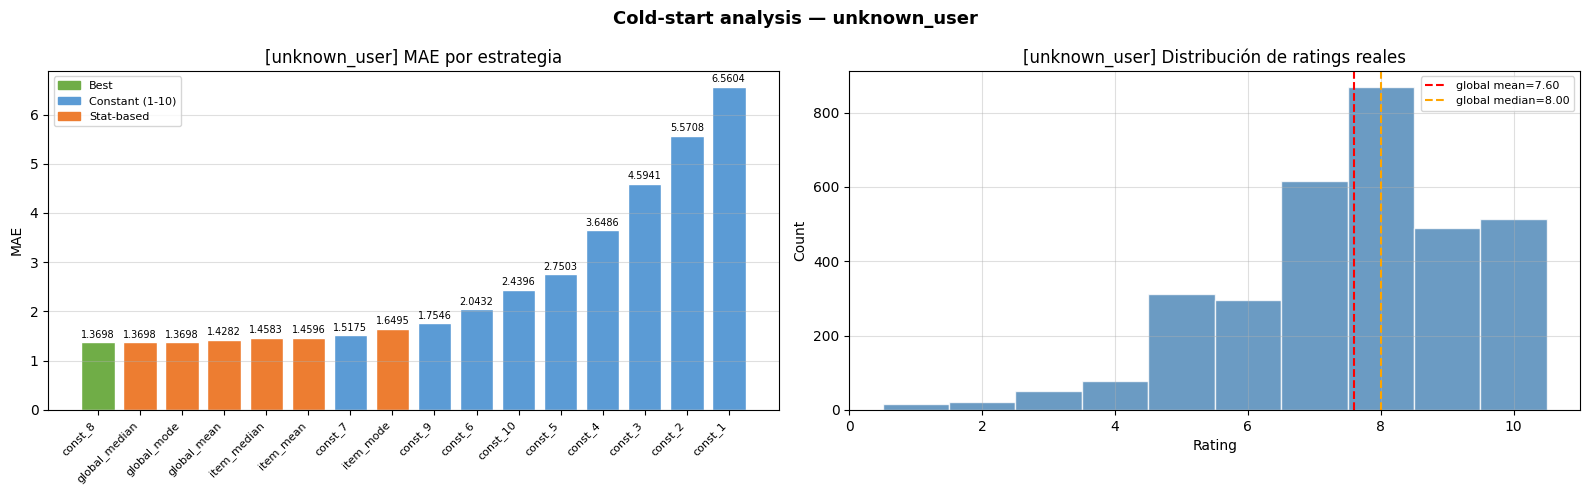


── unknown_item (n=11212) ──────────────────────────────
     strategy      mae
  user_median 1.209329
    user_mean 1.248337
    user_mode 1.323403
      const_8 1.530503
global_median 1.530503
  global_mode 1.530503
  global_mean 1.560968
      const_7 1.607563
      const_9 1.890474
      const_6 2.037103
     const_10 2.528541
      const_5 2.648056
      const_4 3.553157
      const_3 4.502854
      const_2 5.480557
      const_1 6.471459
  → Mejor estrategia: user_median (MAE=1.2093)


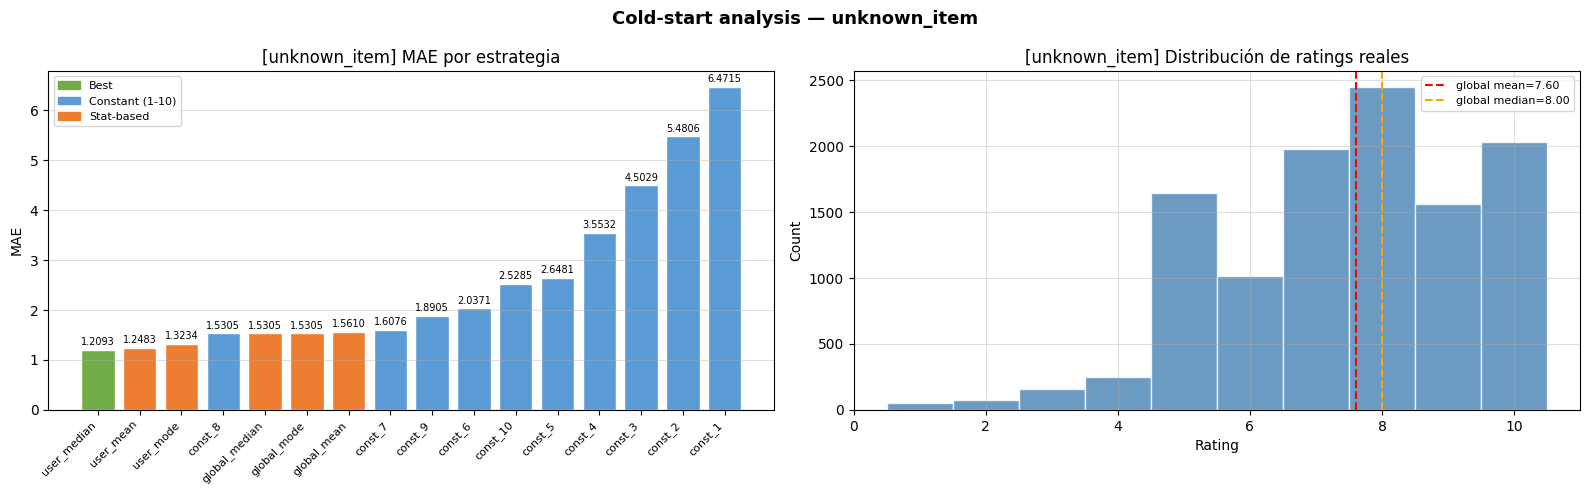


── both_unknown (n=1317) ──────────────────────────────
     strategy      mae
      const_7 1.589977
  global_mean 1.597782
      const_8 1.602885
global_median 1.602885
  global_mode 1.602885
      const_6 1.971906
      const_9 2.053151
      const_5 2.566439
     const_10 2.723614
      const_4 3.423690
      const_3 4.341686
      const_2 5.294609
      const_1 6.276386
  → Mejor estrategia: const_7 (MAE=1.5900)


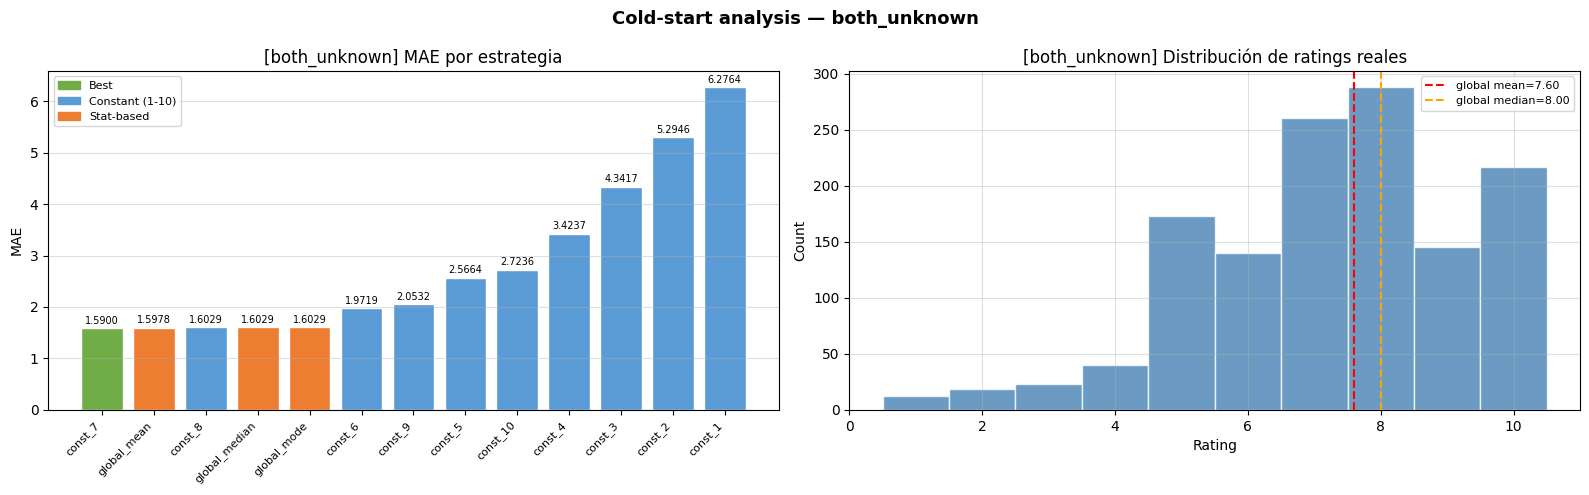

In [16]:
best_strategies, user_stats, item_stats, global_mean = analyze_coldstart(
    x_train, y_train, x_val, y_val, user_map, item_map
)

In [14]:
# {'n_factors': 800, 'lr': 0.016, 'reg': 0.1, 'reg_bias': 0.001}
pmf_params = dict(
    n_factors   = 800,
    lambda_U    = 0.1,  lambda_V  = 0.1,
    lambda_bu   = 0.001, lambda_bi = 0.001,
    lr          = 0.016, n_epochs = 200,
    batch_size  = 256, optimizer = 'sgd',
    use_biases  = True, huber_delta = 1.0,
    log_every   = 5
)
ensemble_info = train_pmf_ensemble(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    pmf_params, n_models=9,
    seeds=[42, 7, 123, 999, 202,91,88816,527,6]
)


════════════════════════════════════════════════════════════
  Modelo 1/9  —  seed=42
════════════════════════════════════════════════════════════
 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     5     0.7142    1.1004     1.5032     0.8221    1.2295     1.6173        ✔ best
    10     0.5935    0.9587     1.3605     0.8015    1.2065     1.5971        ✔ best
    15     0.4911    0.8345     1.2297     0.7942    1.1990     1.5891        ✔ best
    20     0.3915    0.7096     1.0906     0.7922    1.1973     1.5850        ✔ best
    25     0.2983    0.5846     0.9477     0.7923    1.1976     1.5826    no imp 1/3

Early stopping época 27 | best val MAE: 1.1970

  → Stop epoch : 27
  → MAE real   : 1.2282

════════════════════════════════════════════════════════════
  Modelo 2/9  —  seed=7
════════════════════════════════════════════════════════════
 Epoch   Tr Hube

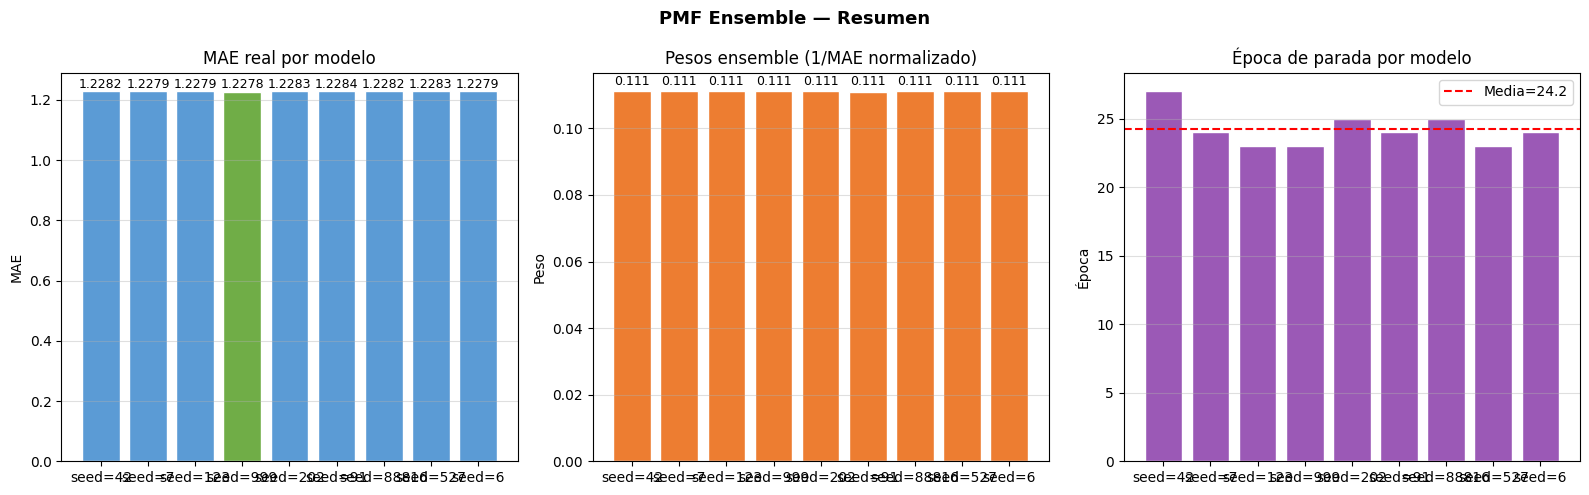

In [17]:
plot_ensemble_summary(ensemble_info)

In [65]:
val_preds_ensemble = weighted_predict(
    ensemble_info, x_val, user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    has_id_col=False
)
mae_ensemble = np.mean(np.abs(val_preds_ensemble - y_val.values))
print(f"\nMAE ensemble (val): {mae_ensemble:.4f}")


Pesos del ensemble:
  seed=42  MAE=1.2315  peso=0.2000
  seed=7  MAE=1.2316  peso=0.2000
  seed=123  MAE=1.2318  peso=0.2000
  seed=999  MAE=1.2317  peso=0.2000
  seed=2024  MAE=1.2317  peso=0.2000


Weighted predict: 100%|██████████| 39036/39036 [00:01<00:00, 19650.63it/s]


MAE ensemble (val): 1.2316


In [18]:
file_test = "data/test.csv"
df_test = pd.read_csv(file_test, header=0)
test_preds_ensemble = weighted_predict(
    ensemble_info, df_test, user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    has_id_col=True
)


Pesos del ensemble:
  seed=42  MAE=1.2282  peso=0.1111
  seed=7  MAE=1.2279  peso=0.1111
  seed=123  MAE=1.2279  peso=0.1111
  seed=999  MAE=1.2278  peso=0.1111
  seed=202  MAE=1.2283  peso=0.1111
  seed=91  MAE=1.2284  peso=0.1111
  seed=88816  MAE=1.2282  peso=0.1111
  seed=527  MAE=1.2283  peso=0.1111
  seed=6  MAE=1.2279  peso=0.1111


Weighted predict: 100%|██████████| 43320/43320 [00:17<00:00, 2432.92it/s]


In [ ]:
test_preds_ensemble.to_csv('submission_ensemble_pmf.csv', index=False)


In [ ]:
full_ensemble_info, user_map_full, item_map_full, global_mean_full = train_full_ensemble(
    x_train, y_train, x_val, y_val,
    ensemble_info, pmf_params,
    best_strategies, user_stats, item_stats,
    seeds=[42, 7, 123, 999, 202,91,88816,527,6]
)

# ── PASO 6: Predicciones finales test ────────────────────────────────────────
submission = weighted_predict(
    full_ensemble_info, df_test, user_map_full, item_map_full,
    best_strategies, user_stats, item_stats, global_mean_full,
    has_id_col=True
)
submission.to_csv('submission_ensemble_pmf2_full.csv', index=False)
print(f"\nSubmission guardado: {len(submission)} predicciones")


Épocas de parada por modelo: [27, 24, 23, 23, 25, 24, 25, 23, 24]
Media de épocas → 24

════════════════════════════════════════════════════════════
  Modelo FULL 1/5  —  seed=42  epochs=24
════════════════════════════════════════════════════════════
 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     5     0.7130    1.0993     1.5021     0.7130    1.0993     1.5021        ✔ best
    10     0.5952    0.9611     1.3627     0.5952    0.9611     1.3627        ✔ best
    15     0.4949    0.8395     1.2348     0.4949    0.8395     1.2348        ✔ best
    20     0.3963    0.7157     1.0978     0.3963    0.7157     1.0978        ✔ best

════════════════════════════════════════════════════════════
  Modelo FULL 2/5  —  seed=7  epochs=24
════════════════════════════════════════════════════════════
 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE    

NameError: name 'x_test' is not defined

In [30]:
submission = weighted_predict(
    full_ensemble_info, df_test, user_map_full, item_map_full,
    best_strategies, user_stats, item_stats, global_mean_full,
    has_id_col=True
)
submission.to_csv('submission_ensemble_pmf2_full.csv', index=False)
print(f"\nSubmission guardado: {len(submission)} predicciones")


Pesos del ensemble:
  seed=42  MAE=1.2282  peso=0.1111
  seed=7  MAE=1.2279  peso=0.1111
  seed=123  MAE=1.2279  peso=0.1111
  seed=999  MAE=1.2278  peso=0.1111
  seed=202  MAE=1.2283  peso=0.1111
  seed=91  MAE=1.2284  peso=0.1111
  seed=88816  MAE=1.2282  peso=0.1111
  seed=527  MAE=1.2283  peso=0.1111
  seed=6  MAE=1.2279  peso=0.1111


Weighted predict:  18%|█▊        | 7894/43320 [00:03<00:16, 2134.62it/s]


KeyboardInterrupt: 

## 3. LightFM — Exploración Individual

| Config | n_factors | λ_U=λ_V | λ_bias | lr | Best val MAE |
|--------|-----------|---------|--------|----|-------------|
| 1 | 800 | 0.500 | 0.002 | 0.016 | ∼1.2338 |
| 2 | 800 | 0.175 | 0.001 | 0.016 | ∼1.2350 |
| 3 | 1200 | 0.500 | 0.010 | 0.016 | ∼1.2601 |
| **4** | **1200** | **0.500** | **0.005** | **0.020** | **1.1963 ✓** |
| 5 | 1200 | 0.600 | 0.0075 | 0.020 | 1.1964 |
| 6 | 1200 | 0.800 | 0.0075 | 0.020 | 1.1964 |
| 7 | 1200 | 1.000 | 0.0075 | 0.020 | 1.1965 |


In [37]:
from lightfm import LightFM
# Ejemplo: géneros de películas como features de ítem
# item_features = {item_idx: [0, 3, 7]}  (índices de géneros)
model = LightFM(n_factors=800, lambda_U=0.5, lambda_V=0.5,
                 lambda_bu=0.002, lambda_bi=0.002,
                 lr=0.016, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True)
model.fit(x_train, y_train, x_val, y_val,
          user_map, item_map,
          item_features=None)   # ← nuevo kwarg opcional

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8954    1.3120     1.6903     0.9296    1.3515     1.7308        ✔ best
     2     0.8390    1.2459     1.6350     0.8970    1.3127     1.7031        ✔ best
     3     0.8014    1.2021     1.5970     0.8791    1.2915     1.6883        ✔ best
     4     0.7724    1.1686     1.5662     0.8674    1.2778     1.6779        ✔ best
     5     0.7484    1.1405     1.5405     0.8590    1.2676     1.6707        ✔ best
     6     0.7278    1.1166     1.5177     0.8528    1.2603     1.6649        ✔ best
     7     0.7098    1.0956     1.4972     0.8481    1.2548     1.6604        ✔ best
     8     0.6936    1.0768     1.4793     0.8443    1.2504     1.6570        ✔ best
     9     0.6789    1.0595     1.4627     0.8412    1.2466     1.6543        ✔ best
    10     0.6656    1.0439     1.4469     0.8389    1.2439     

KeyboardInterrupt: 

In [ ]:
from lightfm import LightFM
# Ejemplo: géneros de películas como features de ítem
# item_features = {item_idx: [0, 3, 7]}  (índices de géneros)
model = LightFM(n_factors=800, lambda_U=0.175, lambda_V=0.175,
                 lambda_bu=0.001, lambda_bi=0.001,
                 lr=0.016, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True)
model.fit(x_train, y_train, x_val, y_val,
          user_map, item_map,
          item_features=None)   # ← nuevo kwarg opcional

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8924    1.3084     1.6872     0.9296    1.3515     1.7309        ✔ best
     2     0.8315    1.2372     1.6268     0.8971    1.3128     1.7032        ✔ best
     3     0.7894    1.1881     1.5836     0.8792    1.2917     1.6883        ✔ best
     4     0.7557    1.1493     1.5473     0.8676    1.2781     1.6779        ✔ best
     5     0.7272    1.1158     1.5161     0.8593    1.2680     1.6706        ✔ best
     6     0.7021    1.0866     1.4877     0.8532    1.2608     1.6649        ✔ best
     7     0.6796    1.0603     1.4617     0.8485    1.2554     1.6602        ✔ best
     8     0.6589    1.0362     1.4381     0.8447    1.2511     1.6568        ✔ best
     9     0.6398    1.0135     1.4158     0.8417    1.2474     1.6539        ✔ best
    10     0.6220    0.9925     1.3942     0.8393    1.2448     

KeyboardInterrupt: 

In [40]:
from lightfm import LightFM
# Ejemplo: géneros de películas como features de ítem
# item_features = {item_idx: [0, 3, 7]}  (índices de géneros)
model = LightFM(n_factors=1200, lambda_U=0.5, lambda_V=0.5,
                 lambda_bu=0.01, lambda_bi=0.01,
                 lr=0.016, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True)
model.fit(x_train, y_train, x_val, y_val,
          user_map, item_map,
          item_features=None)   # ← nuevo kwarg opcional

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8954    1.3120     1.6903     0.9294    1.3513     1.7305        ✔ best
     2     0.8390    1.2459     1.6350     0.8968    1.3125     1.7029        ✔ best
     3     0.8014    1.2021     1.5971     0.8789    1.2913     1.6881        ✔ best
     4     0.7724    1.1686     1.5662     0.8672    1.2777     1.6778        ✔ best
     5     0.7484    1.1404     1.5406     0.8589    1.2674     1.6706        ✔ best
     6     0.7278    1.1165     1.5177     0.8527    1.2601     1.6649        ✔ best


KeyboardInterrupt: 

In [7]:
from lightfm import LightFM
# Ejemplo: géneros de películas como features de ítem
# item_features = {item_idx: [0, 3, 7]}  (índices de géneros)
model = LightFM(n_factors=1200, lambda_U=0.5, lambda_V=0.5,
                 lambda_bu=0.005, lambda_bi=0.005,
                 lr=0.02, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True)
model.fit(x_train, y_train, x_val, y_val,
          user_map, item_map,
          item_features=None)   # ← nuevo kwarg opcional

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8733    1.2856     1.6706     0.8874    1.3056     1.6749        ✔ best
     2     0.8148    1.2175     1.6125     0.8522    1.2646     1.6441        ✔ best
     3     0.7764    1.1726     1.5731     0.8336    1.2426     1.6284        ✔ best
     4     0.7467    1.1384     1.5403     0.8218    1.2291     1.6171        ✔ best
     5     0.7223    1.1101     1.5135     0.8137    1.2197     1.6100        ✔ best
     6     0.7015    1.0857     1.4898     0.8081    1.2133     1.6049        ✔ best
     7     0.6832    1.0647     1.4687     0.8039    1.2086     1.6007        ✔ best
     8     0.6670    1.0455     1.4502     0.8008    1.2052     1.5981        ✔ best
     9     0.6522    1.0287     1.4326     0.7982    1.2024     1.5954        ✔ best
    10     0.6389    1.0129     1.4170     0.7968    1.2008     

KeyboardInterrupt: 

In [ ]:
from lightfm import LightFM
# Ejemplo: géneros de películas como features de ítem
# item_features = {item_idx: [0, 3, 7]}  (índices de géneros)
model = LightFM(n_factors=1200, lambda_U=0.6, lambda_V=0.6,
                 lambda_bu=0.0075, lambda_bi=0.0075,
                 lr=0.02, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True)
model.fit(x_train, y_train, x_val, y_val,
          user_map, item_map,
          item_features=None)   # ← nuevo kwarg opcional

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8743    1.2868     1.6716     0.8875    1.3057     1.6749        ✔ best
     2     0.8167    1.2198     1.6145     0.8522    1.2648     1.6440        ✔ best
     3     0.7792    1.1759     1.5760     0.8337    1.2427     1.6283        ✔ best
     4     0.7501    1.1425     1.5441     0.8218    1.2292     1.6170        ✔ best
     5     0.7264    1.1151     1.5181     0.8137    1.2198     1.6099        ✔ best
     6     0.7061    1.0913     1.4952     0.8081    1.2134     1.6048        ✔ best
     7     0.6885    1.0710     1.4747     0.8039    1.2087     1.6006        ✔ best
     8     0.6727    1.0524     1.4568     0.8008    1.2053     1.5980        ✔ best
     9     0.6584    1.0361     1.4399     0.7982    1.2025     1.5953        ✔ best
    10     0.6455    1.0209     1.4248     0.7968    1.2009     

In [9]:
from lightfm import LightFM
# Ejemplo: géneros de películas como features de ítem
# item_features = {item_idx: [0, 3, 7]}  (índices de géneros)
model = LightFM(n_factors=1200, lambda_U=0.8, lambda_V=0.8,
                 lambda_bu=0.0075, lambda_bi=0.0075,
                 lr=0.02, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True)
model.fit(x_train, y_train, x_val, y_val,
          user_map, item_map,
          item_features=None)   # ← nuevo kwarg opcional

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8757    1.2885     1.6731     0.8875    1.3057     1.6749        ✔ best
     2     0.8195    1.2230     1.6177     0.8522    1.2647     1.6440        ✔ best
     3     0.7831    1.1805     1.5805     0.8336    1.2426     1.6283        ✔ best
     4     0.7551    1.1482     1.5498     0.8217    1.2291     1.6170        ✔ best
     5     0.7323    1.1218     1.5249     0.8136    1.2197     1.6099        ✔ best
     6     0.7128    1.0990     1.5030     0.8080    1.2133     1.6048        ✔ best
     7     0.6958    1.0795     1.4834     0.8038    1.2086     1.6006        ✔ best
     8     0.6806    1.0617     1.4663     0.8008    1.2052     1.5981        ✔ best
     9     0.6669    1.0460     1.4501     0.7982    1.2024     1.5954        ✔ best
    10     0.6545    1.0314     1.4356     0.7968    1.2008     

In [10]:
from lightfm import LightFM
# Ejemplo: géneros de películas como features de ítem
# item_features = {item_idx: [0, 3, 7]}  (índices de géneros)
model = LightFM(n_factors=1200, lambda_U=1, lambda_V=1,
                 lambda_bu=0.0075, lambda_bi=0.0075,
                 lr=0.02, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True)
model.fit(x_train, y_train, x_val, y_val,
          user_map, item_map,
          item_features=None)   # ← nuevo kwarg opcional

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8768    1.2897     1.6743     0.8875    1.3057     1.6749        ✔ best
     2     0.8216    1.2254     1.6200     0.8522    1.2647     1.6440        ✔ best
     3     0.7860    1.1838     1.5838     0.8336    1.2426     1.6283        ✔ best
     4     0.7586    1.1524     1.5540     0.8217    1.2291     1.6170        ✔ best
     5     0.7364    1.1266     1.5298     0.8136    1.2196     1.6099        ✔ best
     6     0.7174    1.1043     1.5084     0.8080    1.2132     1.6048        ✔ best
     7     0.7008    1.0854     1.4894     0.8038    1.2085     1.6006        ✔ best
     8     0.6860    1.0679     1.4728     0.8007    1.2051     1.5981        ✔ best
     9     0.6726    1.0527     1.4569     0.7981    1.2023     1.5954        ✔ best
    10     0.6604    1.0384     1.4428     0.7968    1.2007     

Casos cold-start en validación:
  unknown_user   :  3264 (8.4%)
  unknown_item   : 11212 (28.7%)
  both_unknown   :  1317 (3.4%)

── unknown_user (n=3264) ──────────────────────────────
     strategy      mae
      const_8 1.369792
global_median 1.369792
  global_mode 1.369792
  global_mean 1.428172
  item_median 1.458333
    item_mean 1.459555
      const_7 1.517463
    item_mode 1.649510
      const_9 1.754596
      const_6 2.043199
     const_10 2.439645
      const_5 2.750306
      const_4 3.648591
      const_3 4.594056
      const_2 5.570772
      const_1 6.560355
  → Mejor estrategia: const_8 (MAE=1.3698)


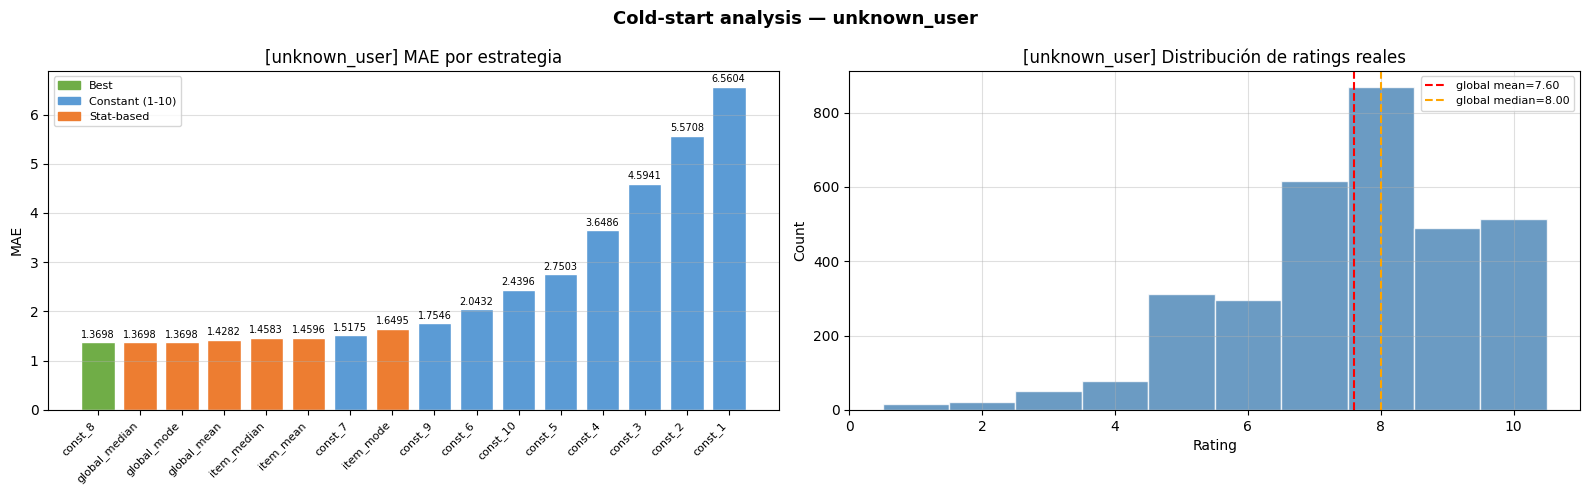


── unknown_item (n=11212) ──────────────────────────────
     strategy      mae
  user_median 1.209329
    user_mean 1.248337
    user_mode 1.323403
      const_8 1.530503
global_median 1.530503
  global_mode 1.530503
  global_mean 1.560968
      const_7 1.607563
      const_9 1.890474
      const_6 2.037103
     const_10 2.528541
      const_5 2.648056
      const_4 3.553157
      const_3 4.502854
      const_2 5.480557
      const_1 6.471459
  → Mejor estrategia: user_median (MAE=1.2093)


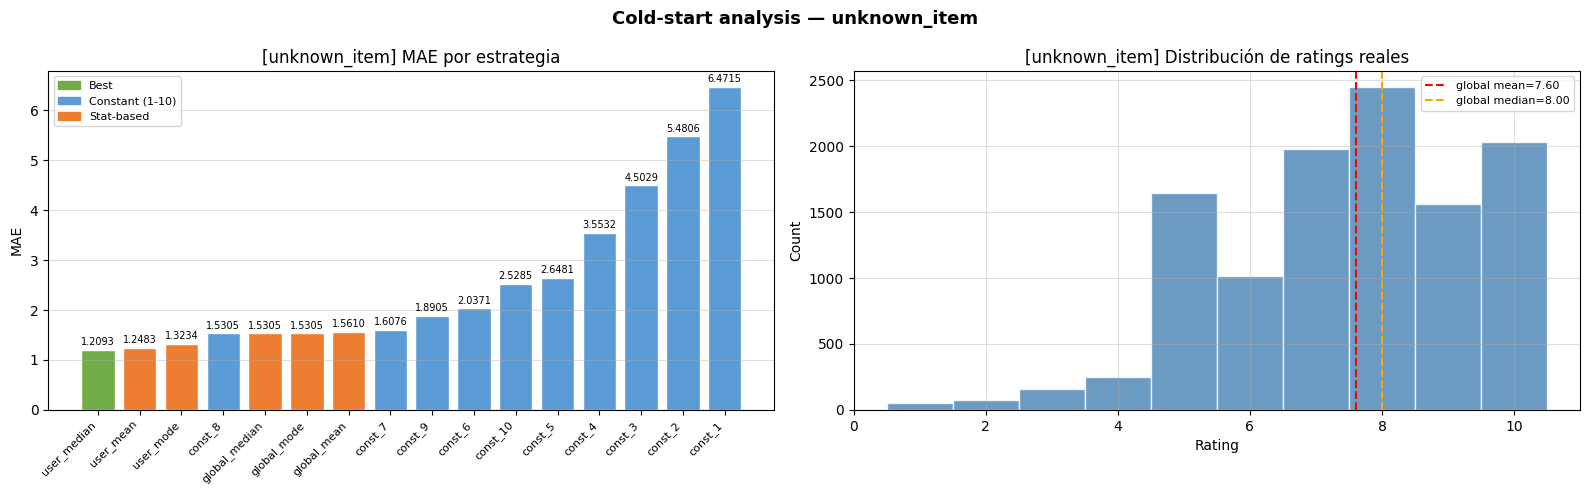


── both_unknown (n=1317) ──────────────────────────────
     strategy      mae
      const_7 1.589977
  global_mean 1.597782
      const_8 1.602885
global_median 1.602885
  global_mode 1.602885
      const_6 1.971906
      const_9 2.053151
      const_5 2.566439
     const_10 2.723614
      const_4 3.423690
      const_3 4.341686
      const_2 5.294609
      const_1 6.276386
  → Mejor estrategia: const_7 (MAE=1.5900)


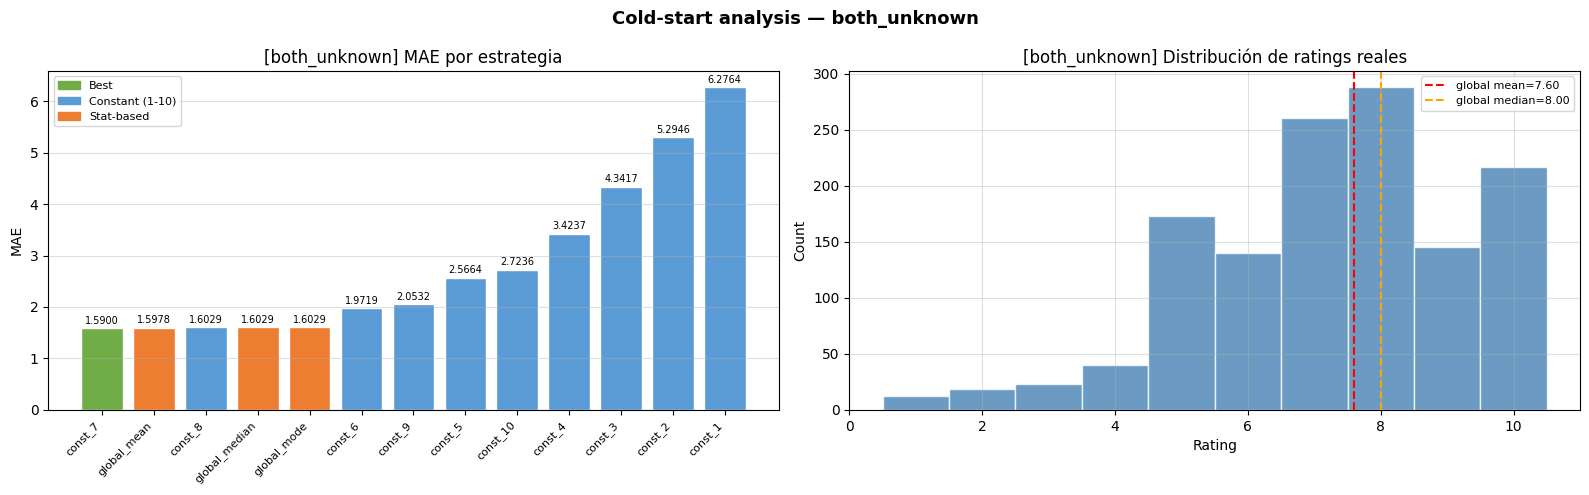

In [22]:
best_strategies, user_stats, item_stats, global_mean = analyze_coldstart(
    x_train, y_train, x_val, y_val, user_map, item_map
)

In [15]:
df_submission = model.predict_test(df_test,user_map,item_map,user_means,item_means,global_mean)
df_submission.to_csv('submission_lightmf.csv')

Predicting: 100%|██████████| 43320/43320 [00:00<00:00, 48264.93it/s]


In [ ]:
df_final = pd.read_csv('submission_lightmf.csv')
df_final.drop(columns=['Unnamed: 0'], inplace=True)
# To remove a single column
df_final.head()


,id,rating
0,0,7.950112
1,1,7.894737
2,2,7.377005
3,3,8.461295
4,4,5.500000


In [27]:
# Save without the index column
df_final.to_csv('submission_lightmf.csv', index=False)

## 4. SVD++ — Exploración Individual

SVD++ extiende PMF con **feedback implícito**: la representación efectiva del usuario es
`p_u = U[u] + |N(u)|^{-½} Σ_{j∈N(u)} Y[j]`, donde `Y` es una matriz de factores
implícitos aprendida a partir de los ítems valorados por el usuario, independientemente
del valor de la valoración. Implementación completa en `svdpp.py`.

| Config | n_factors | λ_U=λ_V=λ_Y | λ_bias | lr | Best val MAE |
|--------|-----------|------------|--------|----|-------------|
| 1 | 200 | 0.5 | 0.01 | 0.030 | 1.1973 |
| 2 | 200 | 0.6 | 0.01 | 0.030 | 1.1973 |
| **3** | **200** | **0.6** | **0.01** | **0.015** | **1.1969 ✓** |

> Bajar `lr` de 0.03 → 0.015 permite más épocas antes del early stopping (26 vs 14),
> lo que da una pequeña mejora.


 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8298    1.2346     1.6258     0.8671    1.2813     1.6572        ✔ best
     2     0.7611    1.1553     1.5543     0.8344    1.2440     1.6286        ✔ best
     3     0.7161    1.1023     1.5058     0.8184    1.2249     1.6151        ✔ best
     4     0.6812    1.0619     1.4651     0.8089    1.2144     1.6049        ✔ best
     5     0.6529    1.0289     1.4324     0.8028    1.2076     1.5996        ✔ best
     6     0.6288    1.0005     1.4041     0.7991    1.2036     1.5962        ✔ best
     7     0.6080    0.9761     1.3792     0.7966    1.2008     1.5939        ✔ best
     8     0.5896    0.9540     1.3574     0.7952    1.1994     1.5927        ✔ best
     9     0.5729    0.9342     1.3370     0.7939    1.1981     1.5915        ✔ best
    10     0.5580    0.9161     1.3186     0.7941    1.1979     

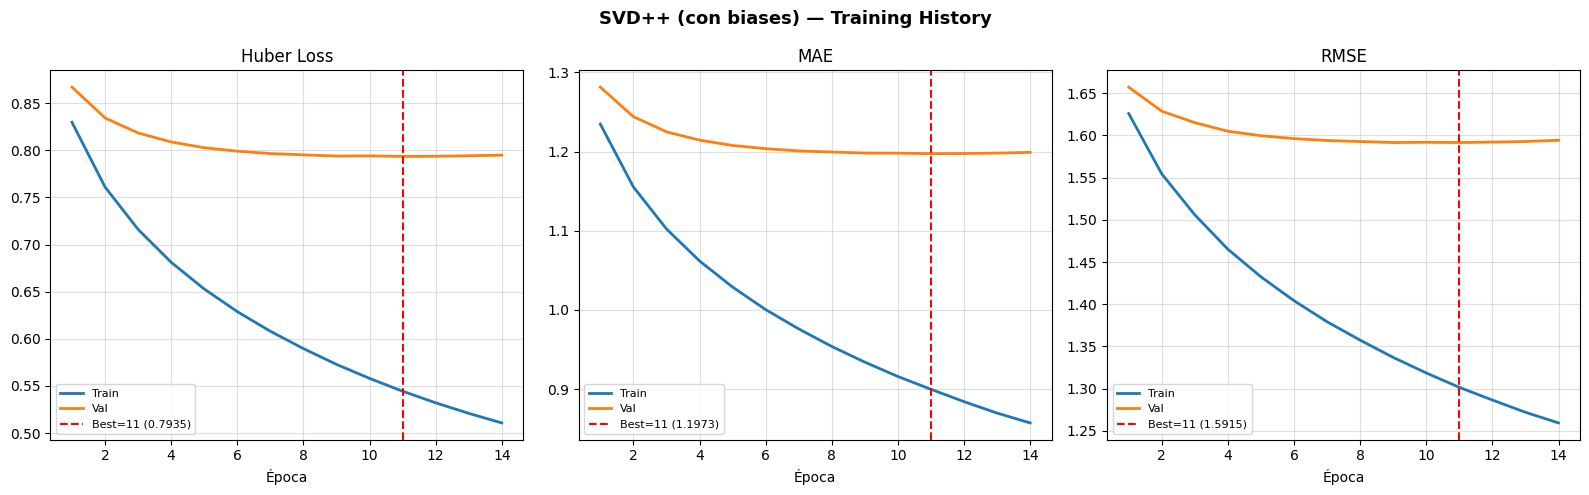

In [11]:
model = SVDpp(
    n_factors   = 200,       # empieza aquí, sube a 100-200 si va bien
    lambda_U    = 0.5,
    lambda_V    = 0.5,
    lambda_bu   = 0.01,
    lambda_bi   = 0.01,
    lambda_Y    = 0.5,
    lr          = 0.03,
    n_epochs    = 200,
    batch_size  = 265,
    optimizer   = 'sgd',    # más rápido que adam aquí
    huber_delta = 1.0,
    log_every   = 1,
    use_biases  = True,
    patience    = 3,
)

model.fit(
    x_train=x_train, y_train=y_train,
    x_val=x_val,     y_val=y_val,
    user_map=user_map, item_map=item_map
)

model.plot_loss()

In [ ]:
df_final = model.predict_test(df_test, user_map, item_map,user_stats,item_stats,global_mean)
df_final.to_csv('submission_svdpp.csv')

Predicting: 100%|██████████| 43320/43320 [00:00<00:00, 52904.48it/s]


 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8319    1.2370     1.6281     0.8670    1.2812     1.6571        ✔ best
     2     0.7650    1.1599     1.5588     0.8343    1.2439     1.6286        ✔ best
     3     0.7216    1.1087     1.5122     0.8184    1.2248     1.6151        ✔ best
     4     0.6880    1.0699     1.4731     0.8088    1.2142     1.6049        ✔ best
     5     0.6609    1.0384     1.4420     0.8027    1.2075     1.5996        ✔ best
     6     0.6380    1.0114     1.4152     0.7990    1.2034     1.5962        ✔ best
     7     0.6182    0.9883     1.3916     0.7965    1.2006     1.5940        ✔ best
     8     0.6007    0.9673     1.3711     0.7951    1.1992     1.5929        ✔ best
     9     0.5848    0.9487     1.3518     0.7939    1.1979     1.5917        ✔ best
    10     0.5707    0.9316     1.3345     0.7941    1.1979     

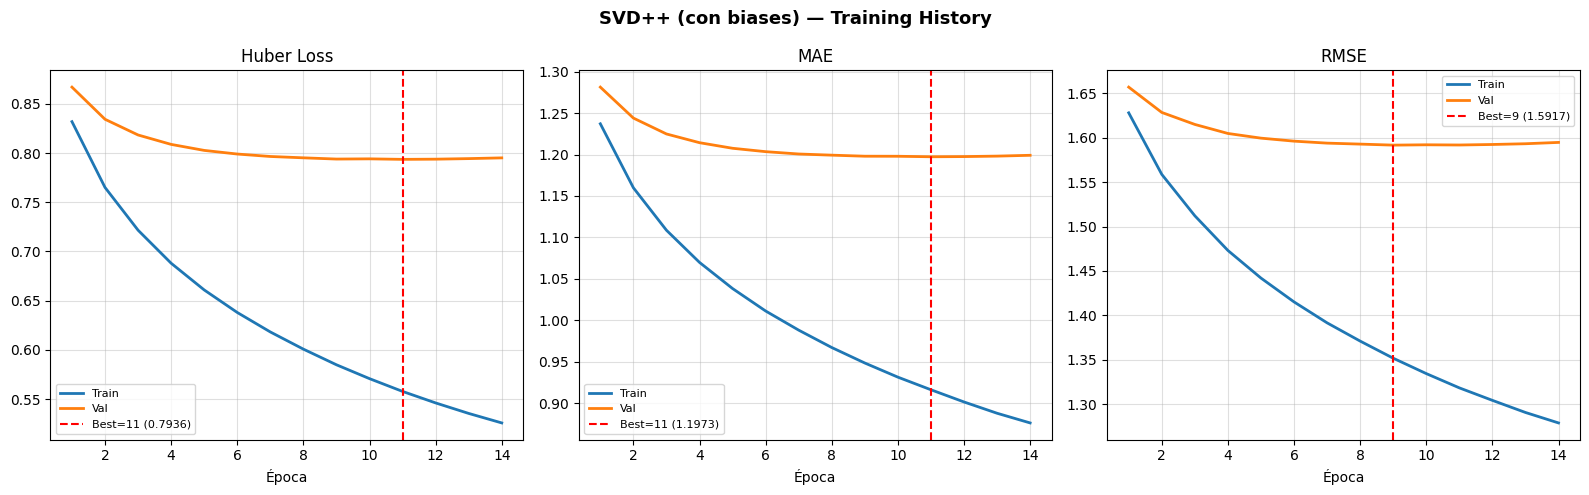

In [ ]:
model = SVDpp(
    n_factors   = 200,       # empieza aquí, sube a 100-200 si va bien
    lambda_U    = 0.6,
    lambda_V    = 0.6,
    lambda_bu   = 0.01,
    lambda_bi   = 0.01,
    lambda_Y    = 0.6,
    lr          = 0.03,
    n_epochs    = 200,
    batch_size  = 265,
    optimizer   = 'sgd',    # más rápido que adam aquí
    huber_delta = 1.0,
    log_every   = 1,
    use_biases  = True,
    patience    = 3,
)

model.fit(
    x_train=x_train, y_train=y_train,
    x_val=x_val,     y_val=y_val,
    user_map=user_map, item_map=item_map
)

model.plot_loss()

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8894    1.3046     1.6849     0.9033    1.3238     1.6892        ✔ best
     2     0.8320    1.2379     1.6280     0.8667    1.2814     1.6567        ✔ best
     3     0.7944    1.1938     1.5900     0.8468    1.2580     1.6399        ✔ best
     4     0.7654    1.1604     1.5588     0.8338    1.2431     1.6275        ✔ best
     5     0.7417    1.1332     1.5332     0.8245    1.2323     1.6193        ✔ best
     6     0.7215    1.1095     1.5107     0.8178    1.2246     1.6132        ✔ best
     7     0.7039    1.0893     1.4909     0.8124    1.2185     1.6083        ✔ best
     8     0.6882    1.0707     1.4733     0.8084    1.2139     1.6048        ✔ best
     9     0.6740    1.0544     1.4568     0.8048    1.2100     1.6012        ✔ best
    10     0.6611    1.0392     1.4419     0.8025    1.2073     

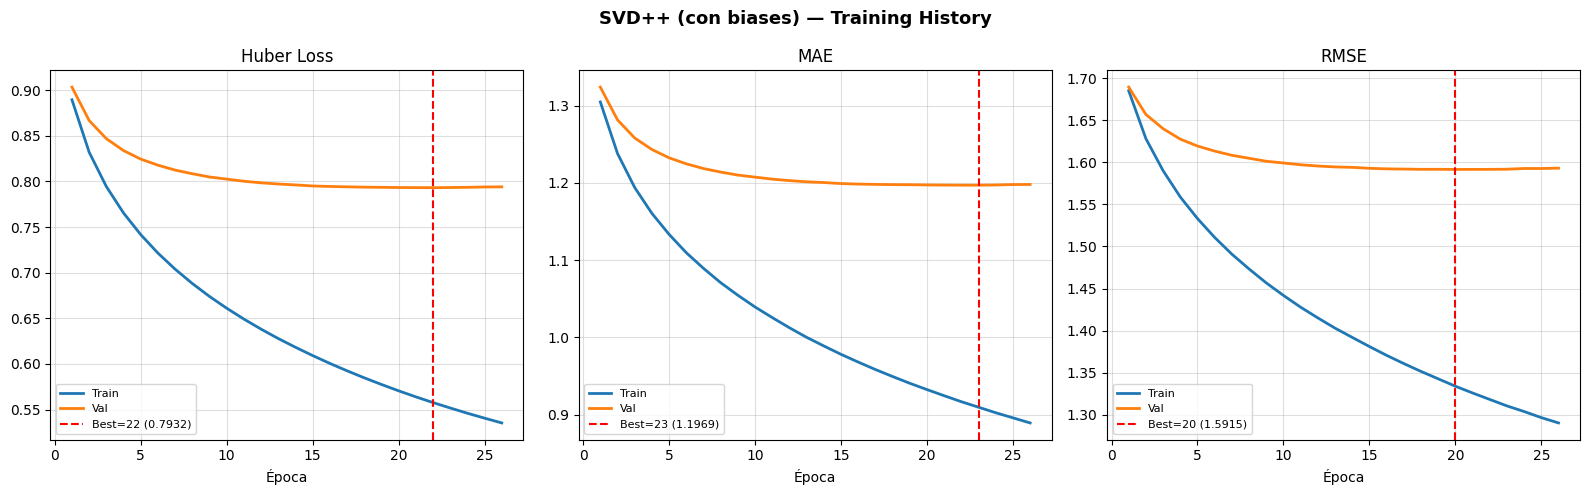

In [ ]:
model = SVDpp(
    n_factors   = 200,       # empieza aquí, sube a 100-200 si va bien
    lambda_U    = 0.6,
    lambda_V    = 0.6,
    lambda_bu   = 0.01,
    lambda_bi   = 0.01,
    lambda_Y    = 0.6,
    lr          = 0.015,
    n_epochs    = 200,
    batch_size  = 265,
    optimizer   = 'sgd',    # más rápido que adam aquí
    huber_delta = 1.0,
    log_every   = 1,
    use_biases  = True,
    patience    = 3,
)

model.fit(
    x_train=x_train, y_train=y_train,
    x_val=x_val,     y_val=y_val,
    user_map=user_map, item_map=item_map
)

model.plot_loss()

In [38]:
df_submission = model.predict_test(df_test, user_map, item_map, user_stats, item_stats, global_mean)
df_submission.to_csv('submission_svdpp.csv', index=False)


Predicting: 100%|██████████| 43320/43320 [00:00<00:00, 50689.96it/s]


## 5. Ensemble Multi-Modelo (PMF + SVDpp + LightFM)

5 modelos de cada tipo × 15 seeds. Pesos calculados automáticamente como función
inversa del MAE individual en validación. Val MAE resultante: **∼1.228**.


In [44]:
# ═══════════════════════════════════════════════════════════════════════════════
# ENSEMBLE MULTI-MODELO: PMF + SVDpp + LightFM
# ═══════════════════════════════════════════════════════════════════════════════
from lightfm import LightFM
MODEL_CLASSES = {'PMF': PMF, 'SVDpp': SVDpp, 'LightFM': LightFM}


# ── Utilidad: predicción para un único modelo genérico ────────────────────────

def _predict_one_model(model, model_type, user_id, item_id,
                       user_map, item_map,
                       user_stats, item_stats, global_mean,
                       cs_unknown_user, cs_unknown_item, cs_both,
                       clip_min=1.0, clip_max=10.0):
    """
    Predicción para un par (user, item) usando cualquiera de los tres modelos.
    Cold-start compartido para todos.
    """
    u_known = user_id in user_map
    i_known = item_id in item_map

    if not u_known and not i_known:
        return _cold_pred_from_strategy(cs_both, user_id, item_id,
                                        user_stats, item_stats, global_mean)
    if not u_known:
        return _cold_pred_from_strategy(cs_unknown_user, user_id, item_id,
                                        user_stats, item_stats, global_mean)
    if not i_known:
        return _cold_pred_from_strategy(cs_unknown_item, user_id, item_id,
                                        user_stats, item_stats, global_mean)

    u = user_map[user_id]
    i = item_map[item_id]

    if model_type == 'PMF':
        p = model.mu + model.b_u[u] + model.b_i[i] + np.dot(model.U[u], model.V[i])

    elif model_type == 'SVDpp':
        p_u = model._user_vector(u)
        p   = model.mu + model.b_u[u] + model.b_i[i] + np.dot(p_u, model.V[i])

    elif model_type == 'LightFM':
        e_u = model._embed_user(u)
        e_i = model._embed_item(i)
        p   = model.mu + model.b_u[u] + model.b_i[i] + np.dot(e_u, e_i)

    return float(np.clip(p, clip_min, clip_max))


# ── Predicción real MAE para cualquier modelo ─────────────────────────────────

def predict_model_real_mae(model, model_type, x_val, y_val,
                           user_map, item_map,
                           best_strategies, user_stats, item_stats, global_mean,
                           clip_min=1.0, clip_max=10.0):
    cs_unknown_user = best_strategies['unknown_user']['strategy']
    cs_unknown_item = best_strategies['unknown_item']['strategy']
    cs_both         = best_strategies['both_unknown']['strategy']

    preds = [
        _predict_one_model(
            model, model_type, row.iloc[0], row.iloc[1],
            user_map, item_map,
            user_stats, item_stats, global_mean,
            cs_unknown_user, cs_unknown_item, cs_both,
            clip_min, clip_max
        )
        for _, row in x_val.iterrows()
    ]

    preds    = np.array(preds)
    real_mae = float(np.mean(np.abs(preds - y_val.values)))
    return preds, real_mae


# ── Entrenamiento del ensemble multi-modelo ───────────────────────────────────

def train_multi_ensemble(x_train, y_train, x_val, y_val,
                         user_map, item_map,
                         best_strategies, user_stats, item_stats, global_mean,
                         ensemble_config, base_seeds=None,
                         clip_min=1.0, clip_max=10.0):
    """
    Entrena todos los modelos definidos en ensemble_config.

    ensemble_config = {
        'PMF'    : {'n_models': 3, 'params': {...}},
        'SVDpp'  : {'n_models': 2, 'params': {...}},
        'LightFM': {'n_models': 2, 'params': {...}},
    }

    Devuelve ensemble_info: lista de dicts con:
        model_type, seed, model, stop_epoch, real_mae, val_preds
    """
    if base_seeds is None:
        base_seeds = [42, 7, 123, 999, 2024, 314, 777, 1337, 88, 256, 55, 66, 77, 88, 99] # RANDOM BASE SEEDS, 15

    ensemble_info = []
    seed_counter  = 0

    for model_type, cfg in ensemble_config.items():
        n_models   = cfg['n_models']
        params     = cfg['params']
        ModelClass = MODEL_CLASSES[model_type]

        if n_models == 0:
            continue

        print(f"\n{'═'*65}")
        print(f"  {model_type}  —  {n_models} modelos")
        print(f"{'═'*65}")

        for idx in range(n_models):
            seed = base_seeds[seed_counter % len(base_seeds)]
            seed_counter += 1

            print(f"\n  [{model_type}] Modelo {idx+1}/{n_models}  —  seed={seed}")
            print(f"  {'─'*55}")

            model = ModelClass(**{**params, 'random_state': seed})
            model.fit(
                x_train, y_train, x_val, y_val,
                user_map, item_map,
                patience=params.get('patience', 3)
            )

            stop_epoch     = len(model.history)
            val_preds, mae = predict_model_real_mae(
                model, model_type, x_val, y_val,
                user_map, item_map,
                best_strategies, user_stats, item_stats, global_mean,
                clip_min, clip_max
            )

            print(f"\n  → Stop epoch : {stop_epoch}")
            print(f"  → MAE real   : {mae:.4f}")

            ensemble_info.append({
                'model_type' : model_type,
                'seed'       : seed,
                'model'      : model,
                'stop_epoch' : stop_epoch,
                'real_mae'   : mae,
                'val_preds'  : val_preds,
            })

    # Resumen
    print(f"\n{'═'*65}")
    print(f"  ENSEMBLE COMPLETO — {len(ensemble_info)} modelos")
    print(f"{'═'*65}")
    for info in ensemble_info:
        print(f"  {info['model_type']:<8}  seed={info['seed']:<5}  "
              f"MAE={info['real_mae']:.4f}  epochs={info['stop_epoch']}")

    return ensemble_info


# ── Predicción ponderada multi-modelo ─────────────────────────────────────────

def weighted_predict_multi(ensemble_info, x, user_map, item_map,
                           best_strategies, user_stats, item_stats, global_mean,
                           clip_min=1.0, clip_max=10.0, has_id_col=False):
    """
    Predicción ensemble ponderada por 1/MAE para cualquier combinación de modelos.
    """
    maes    = np.array([m['real_mae'] for m in ensemble_info])
    weights = 1 / maes
    weights = weights / weights.sum()

    cs_unknown_user = best_strategies['unknown_user']['strategy']
    cs_unknown_item = best_strategies['unknown_item']['strategy']
    cs_both         = best_strategies['both_unknown']['strategy']

    print(f"\nPesos del ensemble ({len(ensemble_info)} modelos):")
    for info, w in zip(ensemble_info, weights):
        print(f"  {info['model_type']:<8} seed={info['seed']:<5}  "
              f"MAE={info['real_mae']:.4f}  peso={w:.4f}")

    ids_out, preds_out = [], []

    for _, row in tqdm(x.iterrows(), total=len(x), desc='Weighted predict'):
        if has_id_col:
            row_id, user_id, item_id = row.iloc[0], row.iloc[1], row.iloc[2]
            ids_out.append(row_id)
        else:
            user_id, item_id = row.iloc[0], row.iloc[1]

        u_known = user_id in user_map
        i_known = item_id in item_map

        # ── Cold start: igual para todos los modelos ──────────────────────────
        if not u_known and not i_known:
            preds_out.append(_cold_pred_from_strategy(
                cs_both, user_id, item_id, user_stats, item_stats, global_mean))
            continue
        if not u_known:
            preds_out.append(_cold_pred_from_strategy(
                cs_unknown_user, user_id, item_id, user_stats, item_stats, global_mean))
            continue
        if not i_known:
            preds_out.append(_cold_pred_from_strategy(
                cs_unknown_item, user_id, item_id, user_stats, item_stats, global_mean))
            continue

        # ── Par conocido: media ponderada de todos los modelos ────────────────
        model_preds = [
            _predict_one_model(
                info['model'], info['model_type'],
                user_id, item_id,
                user_map, item_map,
                user_stats, item_stats, global_mean,
                cs_unknown_user, cs_unknown_item, cs_both,
                clip_min, clip_max
            )
            for info in ensemble_info
        ]

        preds_out.append(float(np.clip(np.dot(weights, model_preds), clip_min, clip_max)))

    if has_id_col:
        return pd.DataFrame({'ID': ids_out, 'rating': preds_out})
    return np.array(preds_out)


# ── Reentrenar sobre train+val ────────────────────────────────────────────────

def train_full_multi_ensemble(x_train, y_train, x_val, y_val,
                              ensemble_info, ensemble_config,
                              best_strategies, user_stats, item_stats,
                              clip_min=1.0, clip_max=10.0):
    """
    Reentrena cada modelo sobre train+val con la media de épocas de su tipo.
    """
    x_full = pd.concat([x_train, x_val]).reset_index(drop=True)
    y_full = pd.concat([y_train, y_val]).reset_index(drop=True)

    sparse_full, user_map_full, item_map_full = create_sparse_matrix(x_full, y_full)
    _, _, global_mean_full = compute_stats(sparse_full)

    # Media de épocas por tipo de modelo
    from collections import defaultdict
    epochs_by_type = defaultdict(list)
    for info in ensemble_info:
        epochs_by_type[info['model_type']].append(info['stop_epoch'])

    mean_epochs = {
        mt: int(np.round(np.mean(eps)))
        for mt, eps in epochs_by_type.items()
    }
    print(f"\nMedia de épocas por tipo:")
    for mt, ep in mean_epochs.items():
        print(f"  {mt:<8}: {ep} épocas  "
              f"(individual: {epochs_by_type[mt]})")

    full_ensemble_info = []

    for info in ensemble_info:
        mt         = info['model_type']
        seed       = info['seed']
        params     = ensemble_config[mt]['params']
        ModelClass = MODEL_CLASSES[mt]
        n_ep       = mean_epochs[mt]

        print(f"\n  [FULL {mt}] seed={seed}  epochs={n_ep}")

        model = ModelClass(**{**params, 'random_state': seed, 'n_epochs': n_ep})
        model.fit(x_full, y_full, x_full, y_full,
                  user_map_full, item_map_full, patience=999)

        full_ensemble_info.append({
            'model_type' : mt,
            'seed'       : seed,
            'model'      : model,
            'real_mae'   : info['real_mae'],   # MAE de val para mantener pesos
        })

    return full_ensemble_info, user_map_full, item_map_full, global_mean_full


# ── Plot resumen multi-modelo ─────────────────────────────────────────────────

def plot_multi_ensemble_summary(ensemble_info):
    type_colors = {'PMF': '#5b9bd5', 'SVDpp': '#ed7d31', 'LightFM': '#70ad47'}

    labels      = [f"{m['model_type']}\nseed={m['seed']}" for m in ensemble_info]
    maes        = [m['real_mae']   for m in ensemble_info]
    stop_epochs = [m.get('stop_epoch', 0) for m in ensemble_info]
    colors      = [type_colors.get(m['model_type'], '#a9a9a9') for m in ensemble_info]
    weights     = 1 / np.array(maes); weights /= weights.sum()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, values, title, ylabel in [
        (axes[0], maes,        'MAE real por modelo',              'MAE'),
        (axes[1], weights,     'Pesos (1/MAE normalizado)',        'Peso'),
        (axes[2], stop_epochs, 'Época de parada por modelo',       'Época'),
    ]:
        bars = ax.bar(range(len(labels)), values, color=colors, edgecolor='white')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_title(title); ax.set_ylabel(ylabel)
        ax.grid(True, axis='y', alpha=0.4)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(values)*0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    if any(m.get('stop_epoch') for m in ensemble_info):
        axes[2].axhline(np.mean(stop_epochs), color='red', linestyle='--',
                        label=f'Media={np.mean(stop_epochs):.1f}')
        axes[2].legend()

    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(color=c, label=t) for t, c in type_colors.items()],
               loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle('Multi-Model Ensemble — Resumen', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

Casos cold-start en validación:
  unknown_user   :  3264 (8.4%)
  unknown_item   : 11212 (28.7%)
  both_unknown   :  1317 (3.4%)

── unknown_user (n=3264) ──────────────────────────────
     strategy      mae
      const_8 1.369792
global_median 1.369792
  global_mode 1.369792
  global_mean 1.428172
  item_median 1.458333
    item_mean 1.459555
      const_7 1.517463
    item_mode 1.649510
      const_9 1.754596
      const_6 2.043199
     const_10 2.439645
      const_5 2.750306
      const_4 3.648591
      const_3 4.594056
      const_2 5.570772
      const_1 6.560355
  → Mejor estrategia: const_8 (MAE=1.3698)


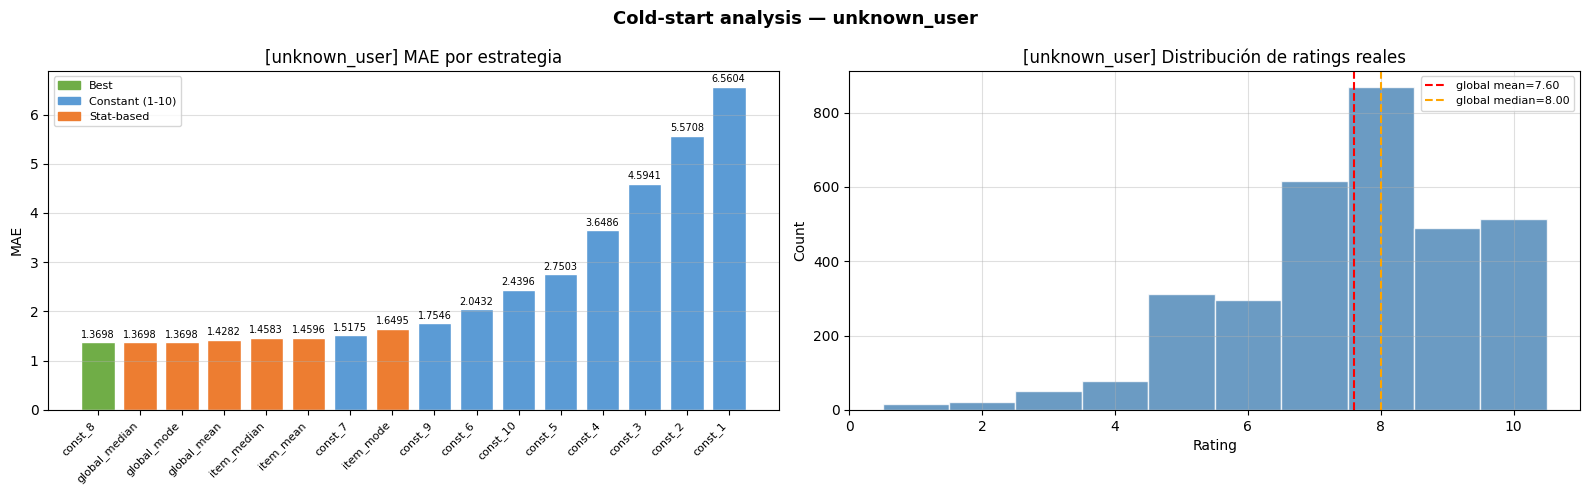


── unknown_item (n=11212) ──────────────────────────────
     strategy      mae
  user_median 1.209329
    user_mean 1.248337
    user_mode 1.323403
      const_8 1.530503
global_median 1.530503
  global_mode 1.530503
  global_mean 1.560968
      const_7 1.607563
      const_9 1.890474
      const_6 2.037103
     const_10 2.528541
      const_5 2.648056
      const_4 3.553157
      const_3 4.502854
      const_2 5.480557
      const_1 6.471459
  → Mejor estrategia: user_median (MAE=1.2093)


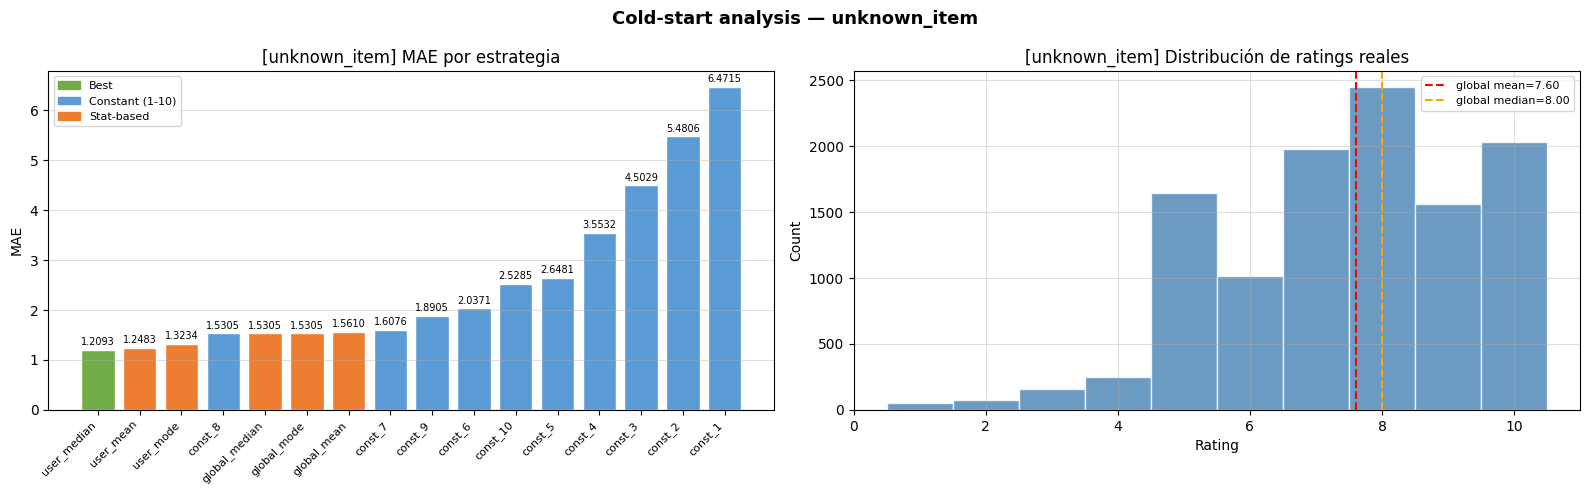


── both_unknown (n=1317) ──────────────────────────────
     strategy      mae
      const_7 1.589977
  global_mean 1.597782
      const_8 1.602885
global_median 1.602885
  global_mode 1.602885
      const_6 1.971906
      const_9 2.053151
      const_5 2.566439
     const_10 2.723614
      const_4 3.423690
      const_3 4.341686
      const_2 5.294609
      const_1 6.276386
  → Mejor estrategia: const_7 (MAE=1.5900)


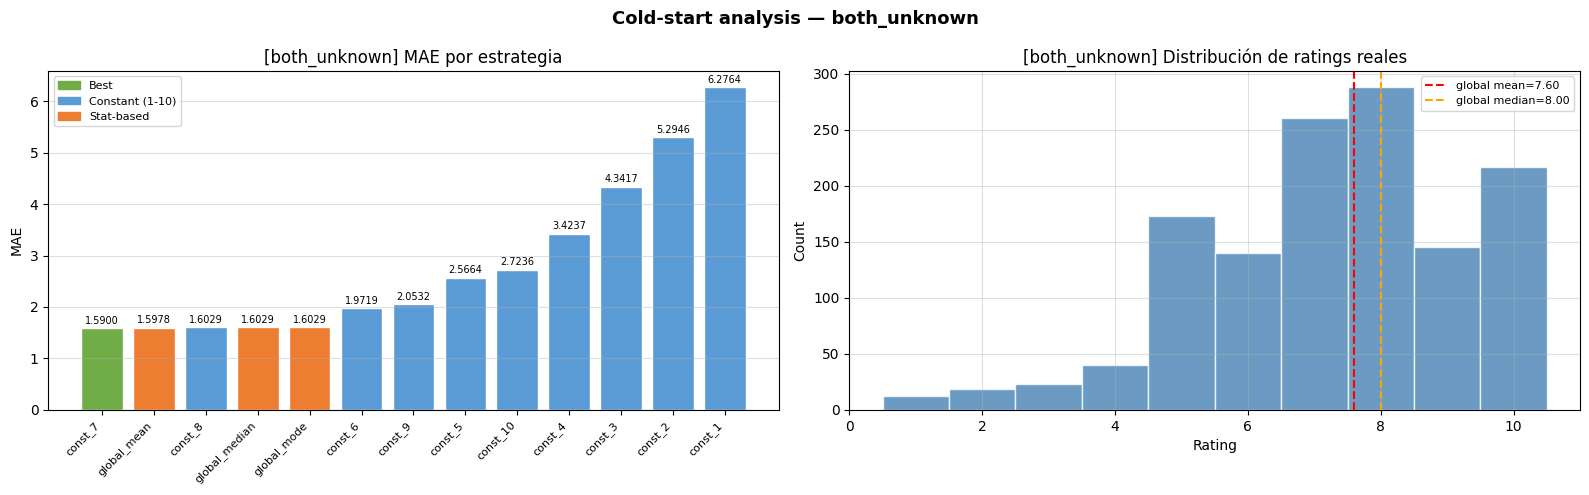

In [55]:
# Configuración: cuántos modelos de cada tipo y sus hiperparámetros
from lightfm import LightFM
ENSEMBLE_CONFIG = {
    'PMF': {
        'n_models': 5,
        'params': dict(
            n_factors=1, lambda_U=1, lambda_V=1,
            lambda_bu=0.1, lambda_bi=0.1,
            lr=0.005, n_epochs=200, batch_size=256,
            optimizer='sgd', use_biases=True,
            huber_delta=1.0, log_every=1
        )
    },
    'SVDpp': {
        'n_models': 5,
        'params': dict(
                n_factors   = 200,       
    lambda_U    = 0.6,
    lambda_V    = 0.6,
    lambda_bu   = 0.01,
    lambda_bi   = 0.01,
    lambda_Y    = 0.6,
    lr          = 0.015,
    n_epochs    = 200,
    batch_size  = 265,
    optimizer   = 'sgd',
    huber_delta = 1.0,
    log_every   = 1,
    patience    = 3,
        )
    },
    'LightFM': {
        'n_models': 5,
        'params': dict(
n_factors=1200, lambda_U=0.8, lambda_V=0.8,
                 lambda_bu=0.0075, lambda_bi=0.0075,
                 lr=0.02, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True
        )
    },
}

# ── PASO 1: Análisis cold-start ───────────────────────────────────────────────
best_strategies, user_stats, item_stats, global_mean = analyze_coldstart(
    x_train, y_train, x_val, y_val, user_map, item_map
)


═════════════════════════════════════════════════════════════════
  PMF  —  5 modelos
═════════════════════════════════════════════════════════════════

  [PMF] Modelo 1/5  —  seed=42
  ───────────────────────────────────────────────────────
 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     1.0595    1.4880     1.8910     1.0462    1.4754     1.8623        ✔ best
     2     0.9975    1.4207     1.8226     0.9888    1.4141     1.7974        ✔ best
     3     0.9588    1.3784     1.7798     0.9544    1.3768     1.7595        ✔ best
     4     0.9305    1.3474     1.7482     0.9311    1.3516     1.7337        ✔ best
     5     0.9082    1.3231     1.7235     0.9138    1.3327     1.7151        ✔ best
     6     0.8896    1.3024     1.7027     0.9003    1.3179     1.7005        ✔ best
     7     0.8740    1.2854     1.6851     0.8894    1.3063     1.6888      

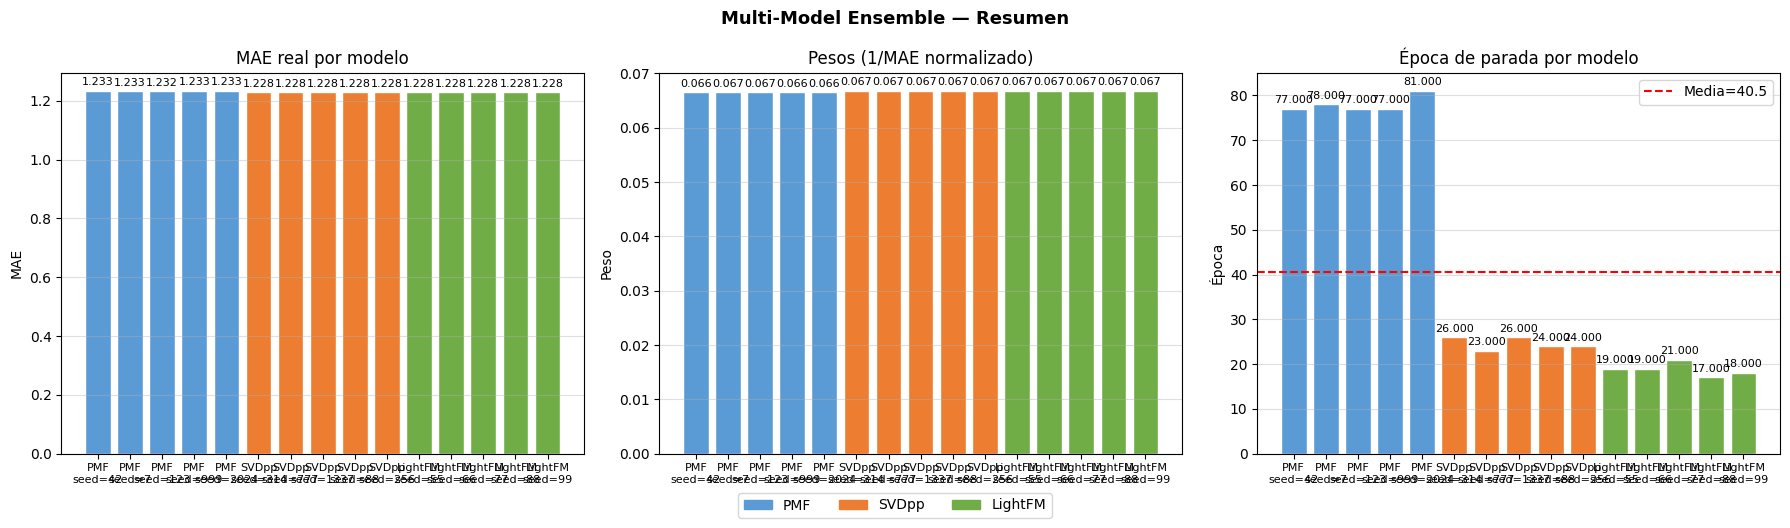


Pesos del ensemble (15 modelos):
  PMF      seed=42     MAE=1.2332  peso=0.0665
  PMF      seed=7      MAE=1.2327  peso=0.0665
  PMF      seed=123    MAE=1.2323  peso=0.0665
  PMF      seed=999    MAE=1.2329  peso=0.0665
  PMF      seed=2024   MAE=1.2328  peso=0.0665
  SVDpp    seed=314    MAE=1.2282  peso=0.0667
  SVDpp    seed=777    MAE=1.2282  peso=0.0667
  SVDpp    seed=1337   MAE=1.2282  peso=0.0667
  SVDpp    seed=88     MAE=1.2282  peso=0.0667
  SVDpp    seed=256    MAE=1.2284  peso=0.0667
  LightFM  seed=55     MAE=1.2280  peso=0.0668
  LightFM  seed=66     MAE=1.2279  peso=0.0668
  LightFM  seed=77     MAE=1.2282  peso=0.0667
  LightFM  seed=88     MAE=1.2279  peso=0.0668
  LightFM  seed=99     MAE=1.2280  peso=0.0668


Weighted predict: 100%|██████████| 39036/39036 [00:29<00:00, 1344.27it/s]



MAE ensemble val: 1.2288

Pesos del ensemble (15 modelos):
  PMF      seed=42     MAE=1.2332  peso=0.0665
  PMF      seed=7      MAE=1.2327  peso=0.0665
  PMF      seed=123    MAE=1.2323  peso=0.0665
  PMF      seed=999    MAE=1.2329  peso=0.0665
  PMF      seed=2024   MAE=1.2328  peso=0.0665
  SVDpp    seed=314    MAE=1.2282  peso=0.0667
  SVDpp    seed=777    MAE=1.2282  peso=0.0667
  SVDpp    seed=1337   MAE=1.2282  peso=0.0667
  SVDpp    seed=88     MAE=1.2282  peso=0.0667
  SVDpp    seed=256    MAE=1.2284  peso=0.0667
  LightFM  seed=55     MAE=1.2280  peso=0.0668
  LightFM  seed=66     MAE=1.2279  peso=0.0668
  LightFM  seed=77     MAE=1.2282  peso=0.0667
  LightFM  seed=88     MAE=1.2279  peso=0.0668
  LightFM  seed=99     MAE=1.2280  peso=0.0668


Weighted predict: 100%|██████████| 43320/43320 [00:18<00:00, 2372.58it/s]


In [56]:
seeds = [42, 7, 123, 999, 2024, 314, 777, 1337, 88, 256, 55, 66, 77, 88, 99] # RANDOM BASE SEEDS

# ── PASO 2: Entrenar ensemble sobre train ─────────────────────────────────────
ensemble_info = train_multi_ensemble(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    ENSEMBLE_CONFIG, seeds
)

plot_multi_ensemble_summary(ensemble_info)

# ── PASO 3: Evaluar en val ────────────────────────────────────────────────────
val_preds = weighted_predict_multi(
    ensemble_info, x_val, user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    has_id_col=False
)
print(f"\nMAE ensemble val: {np.mean(np.abs(val_preds - y_val.values)):.4f}")

test_preds_  = weighted_predict_multi(
    ensemble_info, df_test, user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    has_id_col=True
)
test_preds_.to_csv('submission_multi_ensemble_train_alone.csv', index=False)

In [ ]:
# ── PASO 4: Reentrenar sobre train+val ───────────────────────────────────────
full_ensemble_info, user_map_full, item_map_full, global_mean_full = \
    train_full_multi_ensemble(
        x_train, y_train, x_val, y_val,
        ensemble_info, ENSEMBLE_CONFIG,
        best_strategies, user_stats, item_stats
    )

# ── PASO 5: Predicciones test ─────────────────────────────────────────────────
submission = weighted_predict_multi(
    full_ensemble_info, df_test, user_map_full, item_map_full,
    best_strategies, user_stats, item_stats, global_mean_full,
    has_id_col=True
)
submission.to_csv('submission_multi_ensemble_train_and_val.csv', index=False)


Media de épocas por tipo:
  PMF     : 78 épocas  (individual: [77, 78, 77, 77, 81])
  SVDpp   : 25 épocas  (individual: [26, 23, 26, 24, 24])
  LightFM : 19 épocas  (individual: [19, 19, 21, 17, 18])

  [FULL PMF] seed=42  epochs=78
 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     1.0546    1.4826     1.8856     1.0546    1.4826     1.8856        ✔ best
     2     0.9920    1.4147     1.8166     0.9920    1.4147     1.8166        ✔ best
     3     0.9533    1.3726     1.7739     0.9533    1.3726     1.7739        ✔ best
     4     0.9253    1.3419     1.7428     0.9253    1.3419     1.7428        ✔ best
     5     0.9032    1.3177     1.7183     0.9032    1.3177     1.7183        ✔ best
     6     0.8849    1.2974     1.6981     0.8849    1.2974     1.6981        ✔ best
     7     0.8694    1.2802     1.6809     0.8694    1.2802     1.6809        ✔ best


## 6. Resumen de Resultados

| Modelo / Estrategia | Val MAE | Submission |
|---------------------|---------|------------|
| PMF individual (best grid, n_factors=800) | 1.2446 | — |
| **Ensemble PMF** (9 modelos, seeds distintas) | **1.2316** | `submission_ensemble_pmf.csv` |
| Ensemble PMF (retrain train+val) | — | `submission_ensemble_pmf2_full.csv` |
| LightFM individual (best: f=1200, λ=0.5, lr=0.02) | **1.1963** | `submission_lightmf.csv` |
| SVD++ individual (best: f=200, λ=0.6, lr=0.015) | **1.1969** | `submission_svdpp.csv` |
| **Ensemble multi-modelo** (PMF+SVDpp+LightFM, n_epochs=200) | **∼1.228** | `submission_multi_ensemble_train_and_val.csv` |

> LightFM y SVD++ individualmente superan al ensemble PMF en validación.  
> El ensemble multi-modelo combina los tres tipos buscando aprovechar la diversidad entre
> modelos, aunque no necesariamente supera al mejor modelo individual en val.
